In [545]:
# --- Setup: all imports in one place ---
import glob
import json
import importlib.util
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

In [546]:
from pathlib import Path
RECORDINGS_DIR = Path("recordings-download/*/")
RECORDINGS_BASE = Path("recordings-download/")

score_r1 = "cf_score_p15.json"
score_r2 = "cf_score_selectivity_pw4p6.json"
conversations = "conversation_p15.jsonl"
post_survey_1 = "post_survey_p15.json"
post_survey_2 = "post_survey_pw4p6.json"

In [547]:
# --- Compute scheme-1 SELECTIVITY score for R2 (pw4p6); run to score new entries ---
# Writes a NEW file per participant: cf_score_selectivity_pw4p6.json (never touches
# cf_score_pw4p6.json). Re-run whenever new recordings arrive -- it SKIPS anyone already
# scored unless OVERWRITE=True, so it only processes new entries. Per-move weight =
# 1 - |correct_cols|/|legal_cols|, so pulling off a hard (few-correct) move is worth more
# than an easy one. Reads the live per-move grading (winning_cols / best_cols / optimal)
# from the move log and replays the board just to count legal columns.
import sys
from collections import defaultdict
from datetime import datetime, timezone

_CF = "games/connect_four"
if _CF not in sys.path:
    sys.path.insert(0, _CF)
import engine
from engine import RED, YELLOW, valid_columns, drop, winning_move, is_valid_column

OVERWRITE = False                                    # set True to recompute everyone
_CFG = Path(_CF) / "puzzle_config_w4p6.txt"

def _score_attempt(moves):
    """Scheme 1 for one attempt. Replays the board to get |legal| per move; uses the
    move log's own grading fields. gradable=False if a move lacks live grading."""
    board = engine.load_board(_CFG)
    raw_o = den_o = raw_w = den_w = 0.0; pm = []
    gradable = all(m.get("best_cols") is not None for m in moves)
    for m in sorted(moves, key=lambda r: r["move_number"]):
        legal = len(valid_columns(board)); bc = m.get("best_cols") or []
        wc = m.get("winning_cols") or []; col = m["col"]
        so = (1 - len(bc) / legal) if (legal and bc) else 0.0; den_o += so
        if m.get("optimal"):
            raw_o += so
        sw = None
        if wc and legal:
            sw = 1 - len(wc) / legal; den_w += sw
            if m.get("on_winning_line"):
                raw_w += sw
        pm.append({"move_number": m["move_number"], "col": col, "legal": legal,
                   "n_best": len(bc), "n_win": len(wc), "sel_opt": round(so, 4),
                   "sel_win": (round(sw, 4) if sw is not None else None),
                   "optimal": bool(m.get("optimal")), "on_winning_line": bool(m.get("on_winning_line"))})
        if is_valid_column(board, col):
            drop(board, col, RED)
        ai = m.get("ai_col")
        if ai is not None and not winning_move(board, RED) and is_valid_column(board, ai):
            drop(board, ai, YELLOW)
    return {"raw_opt": raw_o, "norm_opt": (raw_o / den_o if den_o else 0.0),
            "raw_wl": raw_w, "norm_wl": (raw_w / den_w if den_w else 0.0),
            "per_move": pm, "gradable": gradable}

_written = _skipped = 0
for _mf in sorted(glob.glob(str(RECORDINGS_BASE / "*" / "moves_pw4p6.jsonl"))):
    d = Path(_mf).parent
    out_f = d / "cf_score_selectivity_pw4p6.json"
    if out_f.exists() and not OVERWRITE:
        _skipped += 1; continue
    moves = [json.loads(l) for l in open(_mf) if l.strip()]
    if not moves:
        continue
    by = defaultdict(list)
    for m in moves:
        by[m.get("attempt") or 1].append(m)
    att = {a: _score_attempt(ms) for a, ms in by.items()}
    gradable = all(a["gradable"] for a in att.values())
    best = max(att.values(), key=lambda r: r["raw_opt"]); a1 = att[min(att)]
    flat = {}
    _cf = d / "cf_score_pw4p6.json"
    if _cf.exists():
        try: flat = json.load(open(_cf))
        except Exception: pass
    _r = lambda x: round(x, 4)
    json.dump({
        "puzzle": "w4p6",
        "method": "scheme1_selectivity: per-move weight = 1 - |correct|/|legal|; raw rewards hard moves; norm in [0,1]",
        "gradable": gradable,
        "score_selectivity_raw": _r(best["raw_opt"]) if gradable else None,
        "score_selectivity_norm": _r(best["norm_opt"]) if gradable else None,
        "winning_line_selectivity_raw": _r(best["raw_wl"]) if gradable else None,
        "winning_line_selectivity_norm": _r(best["norm_wl"]) if gradable else None,
        "attempt1_selectivity_raw": _r(a1["raw_opt"]) if gradable else None,
        "attempt1_selectivity_norm": _r(a1["norm_opt"]) if gradable else None,
        "attempt_selectivity_raw": [_r(att[a]["raw_opt"]) for a in sorted(att)] if gradable else None,
        "attempts_used": len(att),
        "flat_score": flat.get("score"), "flat_winning_line_score": flat.get("winning_line_score"),
        "per_move_best_attempt": best["per_move"] if gradable else None,
        "computed_at": datetime.now(timezone.utc).isoformat(),
    }, open(out_f, "w"), indent=2)
    _written += 1

print(f"selectivity scoring: wrote {_written}, skipped {_skipped} already-scored. "
      f"(ungradable entries are flagged gradable:false with null scores.) Set OVERWRITE=True to recompute all.")


selectivity scoring: wrote 0, skipped 168 already-scored. (ungradable entries are flagged gradable:false with null scores.) Set OVERWRITE=True to recompute all.


In [548]:
# Participants who had both r1 and r2
all_r1 = glob.glob(str(RECORDINGS_DIR / score_r1))
all_r1 = [x.split("/")[-2] for x in all_r1]
all_r2 = glob.glob(str(RECORDINGS_DIR / score_r2))
all_r2 = [x.split("/")[-2] for x in all_r2]

all_candidates = set(all_r1).intersection(set(all_r2))
all_candidates.remove("p789")

# Drop internal test accounts (e.g. "test1", "test6"). Everything downstream --
# good_pid / bad_pid, demographics, NASA-TLX, dialogue acts, timing, the helpfulness
# join -- derives from all_candidates, so filtering once here excludes them everywhere.
TEST_IDS = sorted(p for p in all_candidates if "test" in p.lower())
all_candidates -= set(TEST_IDS)
print(f"excluded {len(TEST_IDS)} test id(s): {TEST_IDS}")

all_candidates

excluded 1 test id(s): ['test6']


{'p147',
 'p542',
 'p201',
 'p226',
 'p310',
 'p847',
 'p773',
 'p664',
 'p62',
 'p648',
 'p601',
 'p752',
 'p830',
 'p439',
 'p424',
 'p848',
 'p649',
 'p476',
 'p129',
 'p571',
 'p246',
 'p803',
 'p274',
 'p635',
 'p363',
 'p293',
 'p449',
 'p548',
 'p813',
 'p268',
 'p267',
 'p739',
 'p142',
 'p149',
 'p791',
 'p168',
 'p316',
 'p163',
 'p806',
 'p279',
 'p92',
 'p706',
 'p538',
 'p213',
 'p559',
 'p654',
 'p23',
 'p194',
 'p659',
 'p581',
 'p838',
 'p699',
 'p461',
 'p400',
 'p266',
 'p166',
 'p832',
 'p244',
 'p119',
 'p334',
 'p389',
 'p540',
 'p281',
 'p8',
 'p828',
 'p378',
 'p493',
 'p385',
 'p842',
 'p352',
 'p127',
 'p732',
 'p478',
 'p748',
 'p796',
 'p809',
 'p738',
 'p216',
 'p206',
 'p482',
 'p723',
 'p712',
 'p420',
 'p824',
 'p844',
 'p822',
 'p755',
 'p312',
 'p578',
 'p489',
 'p457',
 'p340',
 'p292',
 'p124',
 'p603',
 'p644',
 'p492',
 'p51',
 'p7',
 'p652',
 'p77',
 'p423',
 'p829',
 'p626',
 'p513',
 'p841',
 'p737',
 'p800',
 'p265',
 'p324',
 'p211',
 'p718',
 

In [549]:
len(all_candidates)

166

# Score Differences

In [550]:
# Mean / median / std for a field, across a set of participants.
# nasa_tlx=True reads post_survey["nasa_tlx"][field] instead of a top-level field.
import os
def report_avg(fn, kn, cands=all_candidates, nasa_tlx=False):
    vals = []
    for pid in cands:
        d = json.load(open(RECORDINGS_BASE / pid / fn))
        if not os.path.exists(RECORDINGS_BASE / pid / "conversation_p15.jsonl"):
            continue
        try:
            vals.append(d["nasa_tlx"][kn] if nasa_tlx else int(d[kn]))
        except ValueError:
            vals.append(0)
    return np.mean(vals), np.median(vals), np.std(vals), Counter(vals)

# Round-level score summary across all completers
print(f"{'round':>10} {'metric':>14} {'mean':>6} {'median':>7} {'std':>6}")
for rlabel, fn, kn in [("R1 (AI)", score_r1, "score"), ("R2 (no AI)", score_r2, "score_selectivity_raw")]:
    m, md, sd, ct = report_avg(fn, kn)
    print(f"{rlabel:>10} SCORE {m:>6.2f} {md:>7.1f} {sd:>6.2f}     COUNTER: " + str(ct))

     round         metric   mean  median    std
   R1 (AI) SCORE   2.26     2.0   0.68     COUNTER: Counter({2: 68, 3: 54, 1: 16, 0: 1})
R2 (no AI) SCORE   0.72     1.0   0.71     COUNTER: Counter({0: 60, 1: 58, 2: 21})


# Separate Optimal Moves >= 2 vs. The Rest

In [551]:
# Merged 2-group split: won = score >= 2 (former win + won), lost = the rest.
good_pid, bad_pid = [], []
win_pid = []   # merged into won; kept empty so any legacy references still work
for pid in all_candidates:
    curr_f = json.load(open(RECORDINGS_BASE / pid / score_r2))
    if not os.path.exists(RECORDINGS_BASE / pid / "post_survey_pw4p6.json"):
        continue
    if not os.path.exists(RECORDINGS_BASE / pid / "demographics.json"):
        continue
    # if not os.path.exists(RECORDINGS_BASE / pid / "conversation_p15.jsonl"):
    #     continue
    # conv = open(RECORDINGS_BASE / pid / "conversation_p15.jsonl").readlines()
    # if len(conv) < 2:
    #     continue
    # if curr_f["winning_line_score"] >= 2:
    # if curr_f["score_selectivity_raw"] >= 1.429:
    #     good_pid.append(pid)
    try:
        if curr_f["flat_score"] >= 2:
            good_pid.append(pid)
        elif curr_f["flat_score"] <= 1:
        # else:
            bad_pid.append(pid)
    except TypeError:
        continue
    # elif curr_f["score_selectivity_raw"] <= 0.857:
    #     bad_pid.append(pid)

In [552]:
len(good_pid), len(bad_pid)

(94, 71)

# Demographic Differences

In [553]:
report_avg("demographics.json", "skill_rating", cands=good_pid + win_pid)

(np.float64(1.9113924050632911),
 np.float64(2.0),
 np.float64(0.6201239855147286),
 Counter({2: 51, 1: 16, 3: 11, 0: 1}))

In [554]:
# report_avg("demographics.json", "skill_rating", cands=bad_pid)

In [555]:
# report_avg("demographics.json", "age", cands=good_pid + win_pid)

In [556]:
# report_avg("demographics.json", "age", cands=bad_pid)

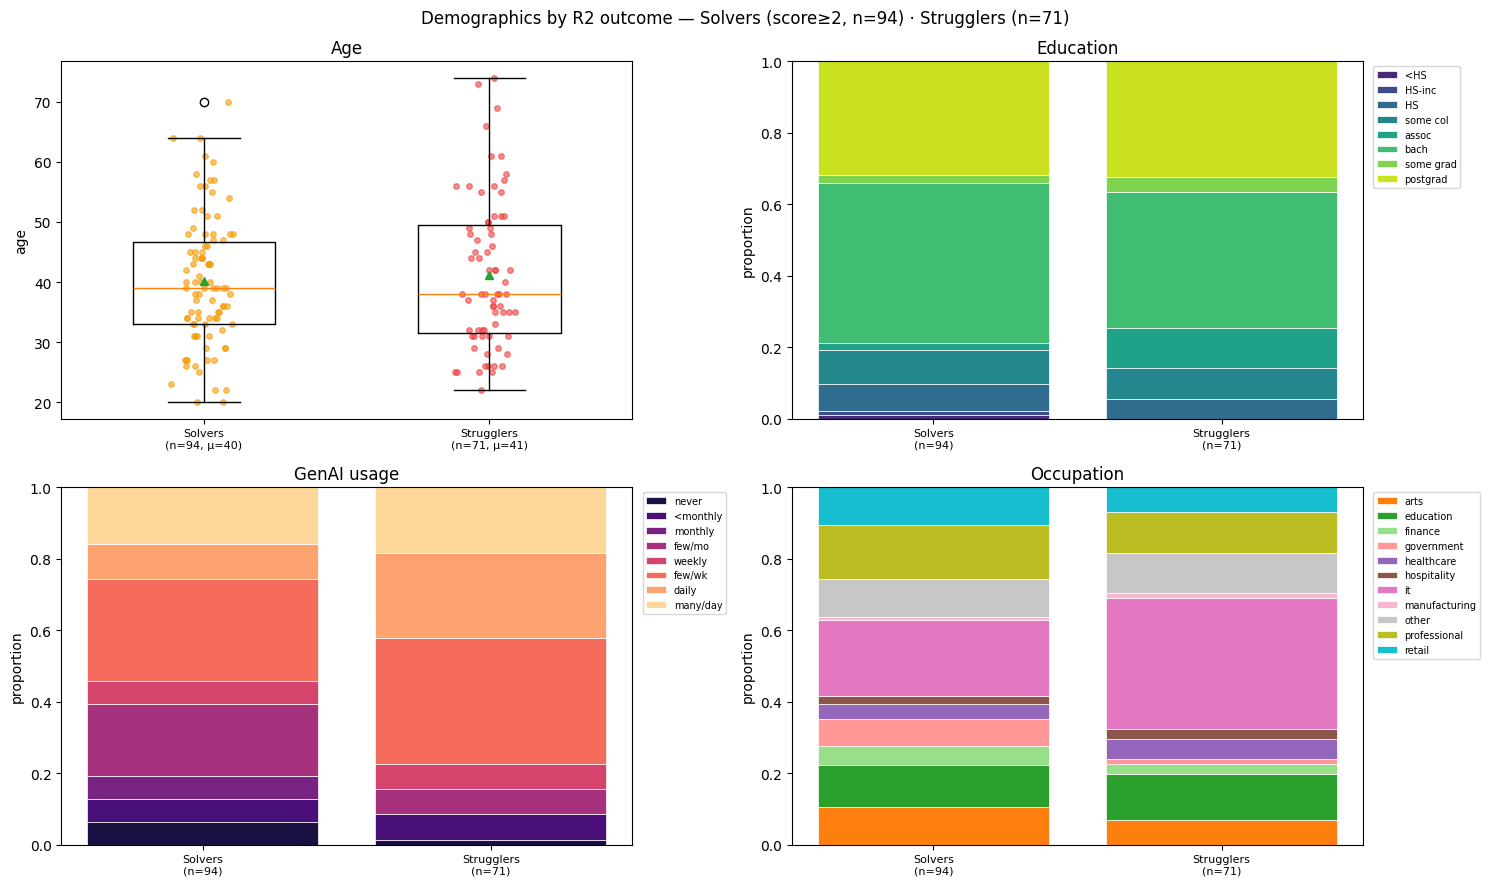

In [557]:
# --- Demographics: good_pid vs win_pid vs bad_pid ---
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def load_demo(cands):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in cands if (RECORDINGS_BASE / pid / "demographics.json").exists()]

dg, dw, db = load_demo(good_pid), load_demo(win_pid), load_demo(bad_pid)
GROUPS = [("Solvers", dg, "#f59e0b"), ("Strugglers", db, "#ef4444")]

# Ordered categories (app option order) + short labels
EDU = (["less_than_hs","hs_incomplete","hs_graduate","some_college","associate","bachelors","some_postgrad","postgrad"],
       ["<HS","HS-inc","HS","some col","assoc","bach","some grad","postgrad"])
GEN = (["never","less_than_monthly","about_monthly","few_times_month","weekly","few_times_week","daily","several_times_day"],
       ["never","<monthly","monthly","few/mo","weekly","few/wk","daily","many/day"])

def props(demos, key, order):
    n = sum(1 for d in demos if d.get(key) in order) or 1
    c = Counter(d.get(key) for d in demos)
    return np.array([c.get(o, 0) / n for o in order])

def stacked(a, key, order, short, title, cmap="viridis"):
    x = np.arange(len(GROUPS))
    P = np.array([props(d, key, order) for _, d, _ in GROUPS])   # (3 groups, n_cats)
    colors = plt.get_cmap(cmap)(np.linspace(0.12, 0.92, len(order)))
    bottoms = np.zeros(len(GROUPS))
    for ci, lab in enumerate(short):
        a.bar(x, P[:, ci], bottom=bottoms, color=colors[ci], label=lab, edgecolor="white", lw=0.5)
        bottoms += P[:, ci]
    a.set_xticks(x); a.set_xticklabels([f"{nm}\n(n={len(d)})" for nm, d, _ in GROUPS], fontsize=8)
    a.set_ylim(0, 1); a.set_ylabel("proportion"); a.set_title(title)
    a.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)

fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# Age — box + jittered points per group
ages = [[d["age"] for d in demos if d.get("age")] for _, demos, _ in GROUPS]
ax[0,0].boxplot(ages, positions=range(len(GROUPS)), widths=0.5, showmeans=True)
rng = np.random.default_rng(0)
for i, ((nm, _, col), v) in enumerate(zip(GROUPS, ages)):
    ax[0,0].scatter(rng.normal(i, 0.05, len(v)), v, s=16, alpha=0.6, color=col)
ax[0,0].set_xticks(range(len(GROUPS)))
ax[0,0].set_xticklabels([f"{nm}\n(n={len(v)}, μ={np.mean(v):.0f})" for (nm,_,_), v in zip(GROUPS, ages)], fontsize=8)
ax[0,0].set_ylabel("age"); ax[0,0].set_title("Age")

stacked(ax[0,1], "education", *EDU, "Education", cmap="viridis")
stacked(ax[1,0], "genai_usage", *GEN, "GenAI usage", cmap="magma")
occ = sorted({d.get("occupation") for _, dm, _ in GROUPS for d in dm if d.get("occupation")})
stacked(ax[1,1], "occupation", occ, occ, "Occupation", cmap="tab20")

fig.suptitle("Demographics by R2 outcome — Solvers (score≥2, n=%d) · Strugglers (n=%d)"
             % (len(dg), len(db)), fontsize=12)
plt.tight_layout(); plt.show()

# NASA-TLX Differences

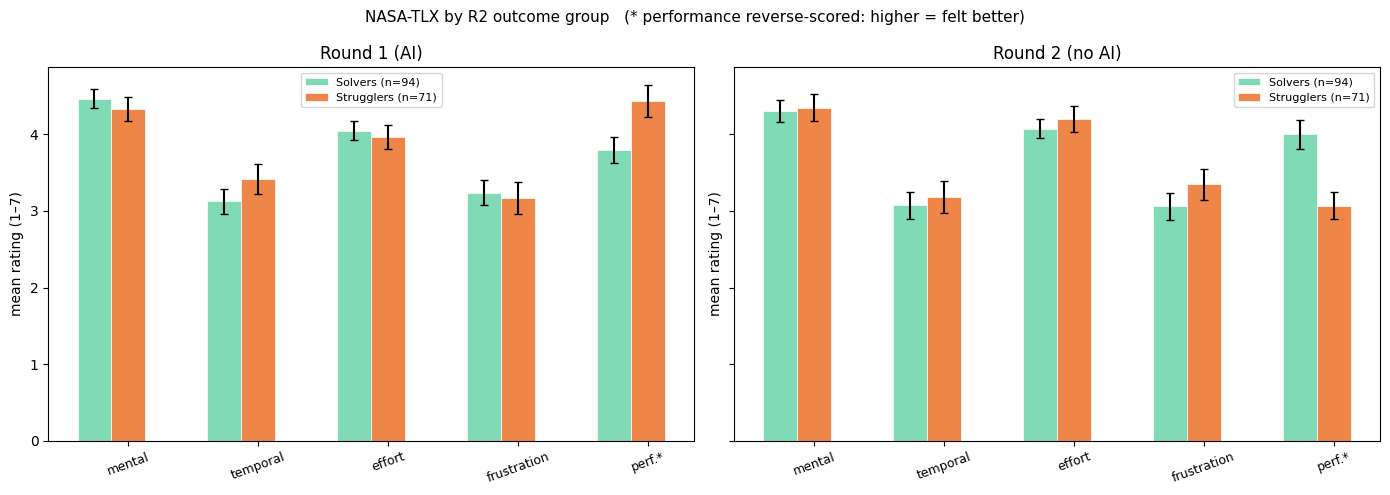

In [558]:
# --- NASA-TLX by R2 outcome group (Solvers / Strugglers), per round ---
# physical_demand was dropped from the instrument (present in only some batch-1
# files), so we compare the 5 current items. performance is reverse-scored:
# a HIGHER rating means the participant felt they did BETTER (lower workload).
TLX_ITEMS = ["mental_demand", "temporal_demand", "effort", "frustration", "performance"]
TLX_SHORT = ["mental", "temporal", "effort", "frustration", "perf.*"]
GROUPST = [("Solvers", good_pid, "#81dab6"), ("Strugglers", bad_pid, "#ef8649")]
ROUNDS = [("Round 1 (AI)", post_survey_1), ("Round 2 (no AI)", post_survey_2)]

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(len(TLX_ITEMS)); w = 0.26
for a, (rlabel, sfile) in zip(ax, ROUNDS):
    for gi, (nm, pids_, col) in enumerate(GROUPST):
        s = [report_avg(sfile, it, cands=pids_, nasa_tlx=True) for it in TLX_ITEMS]
        means = [v[0] for v in s]
        sems = [v[2] / np.sqrt(len(pids_)) for v in s]      # std error of the mean
        a.bar(x + (gi - 1) * w, means, w, yerr=sems, capsize=3, color=col,
              label=f"{nm} (n={len(pids_)})", edgecolor="white", lw=0.5)
    a.set_xticks(x); a.set_xticklabels(TLX_SHORT, rotation=20, fontsize=9)
    a.set_title(rlabel); a.set_ylabel("mean rating (1–7)"); a.legend(fontsize=8)
fig.suptitle("NASA-TLX by R2 outcome group   (* performance reverse-scored: higher = felt better)",
             fontsize=11)
plt.tight_layout(); plt.show()

# Conversation Differences

### Number of Turns

In [559]:
import os
def count_convo_turns(pids):
    turns = []
    for pid in pids:
        convo_f = RECORDINGS_BASE / pid / "conversation_p15.jsonl"
        if os.path.exists(convo_f):
            turns.append(len(open(convo_f).readlines()))
        else:
            turns.append(0)
    return np.mean(turns), np.median(turns), np.std(turns)

print("GOOD (score>=2):", count_convo_turns(good_pid))
print("BAD:", count_convo_turns(bad_pid))

GOOD (score>=2): (np.float64(2.478723404255319), np.float64(2.0), np.float64(2.009174295332963))
BAD: (np.float64(2.1971830985915495), np.float64(2.0), np.float64(1.7248777732558582))


group         n    turns    types   tokens  types/turn    TTR  up P->AI  up AI->P
Solvers      94      2.5     21.6     28.9         9.8   0.83      0.33      0.07
Strugglers   71      2.2     17.2     22.3         8.9   0.83      0.32      0.06
  Mann-Whitney turns          p=0.487
  Mann-Whitney unique words   p=0.194
  Mann-Whitney types/turn     p=0.459
  Mann-Whitney TTR            p=0.852
  Mann-Whitney uptake P->AI   p=0.684
  Mann-Whitney uptake AI->P   p=0.079


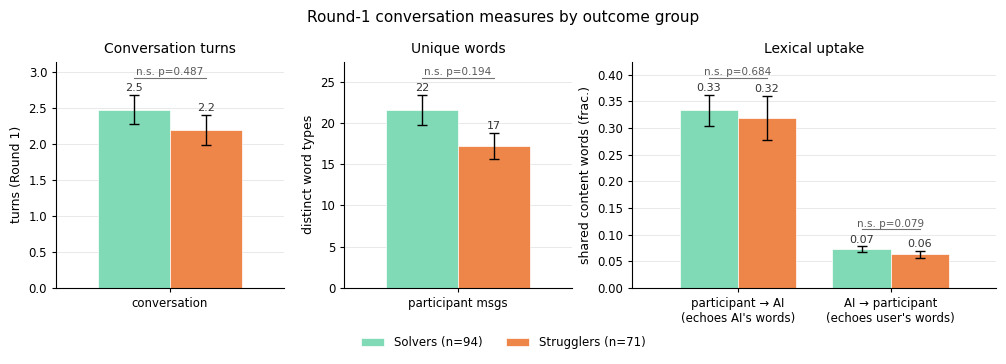

In [560]:
# --- R1 conversation measures: turns, unique words, lexical uptake (Solvers vs Strugglers) ---
# Three panels on the same population as the turns bar chart above.
#  * turns        -- exchanges in conversation_p15.jsonl (one line = one user+assistant pair)
#  * unique words -- distinct word TYPES across a participant's own R1 messages. Grows with
#                    turn count by construction, so the printed table also carries
#                    types-per-turn and TTR (types/tokens) as length-controlled companions.
#  * uptake       -- share of a speaker's CONTENT words that already appeared in the partner's
#                    immediately preceding message (Jaccard-style directional overlap):
#                      participant -> AI : user msg i vs assistant reply i-1  (needs >= 2 turns)
#                      AI -> participant : assistant reply i vs user msg i
#                    This is lexical uptake only -- it measures word reuse, not whether the
#                    idea was actually taken up. Domain vocabulary ("column", "diagonal") is
#                    unavoidable and inflates both directions; flip EXCLUDE_GAME_WORDS to see
#                    uptake with the Connect-Four vocabulary held out.
import re
from scipy.stats import mannwhitneyu

EXCLUDE_GAME_WORDS = False

STOP = set("""a an the and or but if then than so because as of at by for with about into
onto from to in on out up down over under again is are was were be been being am do does did
doing have has had having i you he she it we they me my your his her its our their this that
these those there here what which who whom when where why how all any both each few more most
other some such no nor not only own same too very can will just should now would could may
might must shall im ive youre dont doesnt didnt cant wont thats theres ill id well ok okay yes
yeah no oh hmm think thanks thank please sure lets let get got""".split())

GAME_WORDS = set("""column columns col cols row rows red reds yellow yellows move moves moving
play plays played playing win wins winning won lose loses lost board piece pieces game games
four three two connect diagonal diagonally vertical vertically horizontal horizontally block
blocks blocking opponent turn drop drops threat threats c1 c2 c3 c4 c5 c6 c7 r1 r2 r3 r4 r5
r6""".split())

TOKEN = re.compile(r"[a-z][a-z']*|\d+")

def _toks(s):
    return TOKEN.findall((s or "").lower())

def _content(s):
    """Content-word SET for uptake: stopwords out, 1-2 char tokens out."""
    drop = STOP | (GAME_WORDS if EXCLUDE_GAME_WORDS else set())
    return {w for w in _toks(s) if len(w) > 2 and w not in drop}

def _uptake(cur, prev):
    """Share of the current message's content words seen in the partner's previous one."""
    return len(cur & prev) / len(cur) if cur else np.nan

def convo_measures(pid):
    """Per-participant R1 conversation measures (nan where a measure is undefined)."""
    f = RECORDINGS_BASE / pid / "conversation_p15.jsonl"
    ex = [json.loads(l) for l in open(f) if l.strip()] if f.exists() else []
    if not ex:
        return dict(turns=0, types=0, tokens=0, ttr=np.nan,
                    types_per_turn=np.nan, up_user=np.nan, up_ai=np.nan)
    utoks = [t for e in ex for t in _toks(e.get("user"))]
    # participant echoing the AI's words (skips turn 0 -- no prior AI message to echo)
    up_user = [_uptake(_content(ex[i].get("user")), _content(ex[i - 1].get("assistant")))
               for i in range(1, len(ex))]
    # AI echoing the participant's words (defined on every exchange)
    up_ai = [_uptake(_content(e.get("assistant")), _content(e.get("user"))) for e in ex]
    nanmean = lambda v: np.nanmean(v) if len(v) and not np.all(np.isnan(v)) else np.nan
    return dict(turns=len(ex), types=len(set(utoks)), tokens=len(utoks),
                ttr=len(set(utoks)) / len(utoks) if utoks else np.nan,
                types_per_turn=len(set(utoks)) / len(ex),
                up_user=nanmean(up_user), up_ai=nanmean(up_ai))

GRP_C = [("Solvers", good_pid, "#81dab6"), ("Strugglers", bad_pid, "#ef8649")]
M = {nm: [convo_measures(p) for p in pids_] for nm, pids_, _ in GRP_C}

def _vals(nm, key):
    return np.array([m[key] for m in M[nm] if np.isfinite(m[key])], dtype=float)

print(f"{'group':<11}{'n':>4}{'turns':>9}{'types':>9}{'tokens':>9}{'types/turn':>12}"
      f"{'TTR':>7}{'up P->AI':>10}{'up AI->P':>10}")
for nm, pids_, _ in GRP_C:
    r = [_vals(nm, k).mean() for k in
         ("turns", "types", "tokens", "types_per_turn", "ttr", "up_user", "up_ai")]
    print(f"{nm:<11}{len(M[nm]):>4}{r[0]:>9.1f}{r[1]:>9.1f}{r[2]:>9.1f}{r[3]:>12.1f}"
          f"{r[4]:>7.2f}{r[5]:>10.2f}{r[6]:>10.2f}")
for k, lab in [("turns", "turns"), ("types", "unique words"), ("types_per_turn", "types/turn"),
               ("ttr", "TTR"), ("up_user", "uptake P->AI"), ("up_ai", "uptake AI->P")]:
    p = mannwhitneyu(_vals("Solvers", k), _vals("Strugglers", k), alternative="two-sided").pvalue
    print(f"  Mann-Whitney {lab:<14} p={p:.3f}")

def draw(ax, keys, xlabels, title, ylabel, fmt="{:.0f}", legend=False):
    """Grouped bars: one x-category per key, one bar per group. SEM error bars +
    Mann-Whitney bracket per category. y-limit is sized from the drawn bars."""
    W = 0.38 if len(keys) > 1 else 0.46
    tops = {}
    for gi, (nm, pids_, col) in enumerate(GRP_C):
        for ci, k in enumerate(keys):
            v = _vals(nm, k)
            m, s = v.mean(), v.std() / np.sqrt(len(v))
            x = ci + (gi - 0.5) * W
            ax.bar(x, m, W, yerr=s, capsize=3.5, color=col, edgecolor="white", lw=0.5,
                   error_kw=dict(lw=1.0),
                   label=f"{nm} (n={len(pids_)})" if legend and ci == 0 else None)
            tops[gi, ci] = m + s
    PAD = 0.055 * max(tops.values())
    for gi, (nm, _, _) in enumerate(GRP_C):
        for ci, k in enumerate(keys):
            v = _vals(nm, k)
            ax.text(ci + (gi - 0.5) * W, tops[gi, ci] + 0.35 * PAD, fmt.format(v.mean()),
                    ha="center", fontsize=8, color="0.2")
    ytop = 0
    for ci, k in enumerate(keys):
        p = mannwhitneyu(_vals("Solvers", k), _vals("Strugglers", k),
                         alternative="two-sided").pvalue
        y = max(tops[0, ci], tops[1, ci]) + 1.6 * PAD
        ax.plot([ci - W / 2, ci + W / 2], [y, y], color="0.45", lw=0.8)
        stars = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
        ax.text(ci, y + 0.25 * PAD, f"{stars} p={p:.3f}", ha="center", fontsize=7.5, color="0.35")
        ytop = max(ytop, y + 1.5 * PAD)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(xlabels, fontsize=8.5)
    ax.set_xlim(-0.5 - W / 2, len(keys) - 0.5 + W / 2)
    ax.set_ylim(0, ytop)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=8.5, length=3)
    ax.grid(axis="y", lw=0.4, color="0.85"); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.5),
                         gridspec_kw=dict(width_ratios=[1, 1, 1.6]))
draw(axes[0], ["turns"], ["conversation"], "Conversation turns", "turns (Round 1)",
     fmt="{:.1f}", legend=True)
draw(axes[1], ["types"], ["participant msgs"], "Unique words", "distinct word types")
draw(axes[2], ["up_user", "up_ai"], ["participant → AI\n(echoes AI's words)",
                                     "AI → participant\n(echoes user's words)"],
     "Lexical uptake", "shared content words (frac.)", fmt="{:.2f}")
axes[2].set_ylim(0, min(1.0, axes[2].get_ylim()[1]))
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=8.5, ncol=2,
           loc="lower center", bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Round-1 conversation measures by outcome group", fontsize=11)
fig.tight_layout(rect=(0, 0.06, 1, 0.97), pad=0.5); plt.show()


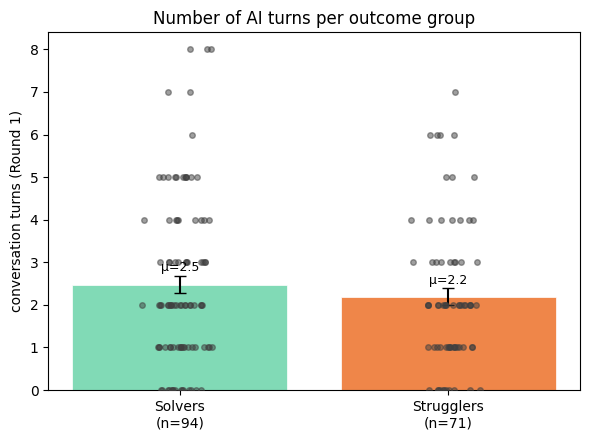

In [561]:
# Bar chart: mean number of conversation turns per outcome group (SEM error bars).
def turns_list(pids):
    out = []
    for pid in pids:
        convo_f = RECORDINGS_BASE / pid / "conversation_p15.jsonl"
        out.append(sum(1 for _ in open(convo_f)) if convo_f.exists() else 0)
    return out

GRP = [("Solvers", good_pid, "#81dab6"), ("Strugglers", bad_pid, "#ef8649")]
fig, ax = plt.subplots(figsize=(6, 4.5))
for i, (nm, pids_, col) in enumerate(GRP):
    t = turns_list(pids_)
    mean, sem = np.mean(t), np.std(t) / np.sqrt(len(t))
    ax.bar(i, mean, yerr=sem, capsize=4, color=col, edgecolor="white", lw=0.5)
    ax.scatter(np.random.default_rng(0).normal(i, 0.06, len(t)), t, s=16, alpha=0.5, color="0.25", zorder=3)
    ax.text(i, mean + sem + 0.1, f"μ={mean:.1f}", ha="center", fontsize=9)
ax.set_xticks(range(len(GRP)))
ax.set_xticklabels([f"{nm}\n(n={len(p)})" for nm, p, _ in GRP])
ax.set_ylabel("conversation turns (Round 1)")
ax.set_title("Number of AI turns per outcome group")
plt.tight_layout(); plt.show()

### Dialogue Acts

In [562]:
# Annotate each Round-1 user turn with the LLM panel (writes one file per participant).
# Slow + hits APIs (3 models x every user turn), so it SKIPS participants already
# annotated. Set OVERWRITE = True to force a re-run.
from dialogue_act_annotation import DialogueActSuite
import dotenv
dotenv.load_dotenv()

da = DialogueActSuite()
print(da.annotators)
OVERWRITE = False

pids = sorted(all_candidates)
for n, pid in enumerate(pids, 1):
    if "test" in pid:
        continue
    convo_f = RECORDINGS_BASE / pid / "conversation_p15.jsonl"
    if not convo_f.exists():
        continue
    out_f = RECORDINGS_BASE / pid / "annotated_conversation_p15.jsonl"
    if out_f.exists() and out_f.stat().st_size > 0 and not OVERWRITE:
        print(f"[{n}/{len(pids)}] {pid[:8]} already annotated — skipping")
        continue

    turns = [json.loads(l) for l in open(convo_f) if l.strip()]
    print(f"[{n}/{len(pids)}] {pid[:8]} annotating {len(turns)} turns...")
    with open(out_f, "w") as w:
        for curr_l in turns:
            utt = (curr_l.get("user") or "").strip()
            curr_l["annotation_user"] = da(utterance=utt) if utt else None
            w.write(json.dumps(curr_l) + "\n")

{'llama': predict = Predict(StringSignature(utterance, taxonomy -> reasoning, dialogue_acts
    instructions='Given an utterance from a user talking to an AI assistant while solving a Connect Four puzzle, first split it into clauses, then classify each clause into the dialogue acts that apply per the taxonomy provided. Output all applicable acts.\n\nDisambiguating the question-type acts (these are easily confused — read carefully):\n- "Solution Request": an OPEN request for the assistant to supply the move/answer, with NO specific candidate move proposed by the user. E.g. "what\'s the best move?", "what now?", "any advice?", "just tell me what to play".\n- "Common Ground Question": the user proposes a SPECIFIC candidate move (or their own read of the position) and asks the assistant to confirm/evaluate it. E.g. "is column 3 good?", "was my last move good?", "would 3/4 be better?".\n- "Knowledge Deficit Question": asks about a concept, rule, or the board (e.g. threats), or clarifies som

In [563]:
# Build a tidy LONG dataframe: one row per (turn, dialogue act).
import pandas as pd

def normalize_ann(ann):
    """Canonicalize a stored annotation. Handles both the current dict form and
    the legacy tuple form [consensus, votes, per_model] (serialized as a list) so
    old annotated files don't need re-running."""
    if ann is None:
        return None
    if isinstance(ann, dict):
        return ann
    consensus, votes, per_model = ann                       # legacy list form
    n_valid = sum(v is not None for v in per_model.values())
    confidence = {a: votes[a] / n_valid for a in votes} if n_valid else {}
    no_majority = not consensus and bool(votes)
    final = consensus if consensus else [a for a in votes]  # no-majority -> union
    return {"final": final, "consensus": consensus, "votes": votes,
            "confidence": confidence, "per_model": per_model, "n_valid": n_valid,
            "no_majority": no_majority, "needs_review": no_majority or n_valid < 2,
            "arbiter_used": False}

group_of = {**{p: "win" for p in win_pid}, **{p: "won" for p in good_pid}, **{p: "lost" for p in bad_pid}}

# Manual relabels for acts that don't fit this human<->AI setting.
# "Correct Answer" (student answering a tutor) misfires on terse move
# statements like "Column 4" -> treat as Think Aloud.
ACT_REMAP = {"Correct Answer": "Think Aloud", "Social Coordination Action": "Metacomment", "Forced Choice": "Metacomment"}

rows = []
for pid in good_pid + bad_pid:
    convo_f = RECORDINGS_BASE / pid / "annotated_conversation_p15.jsonl"
    if not convo_f.exists():
        continue
    for i, l in enumerate(open(convo_f)):
        curr_l = json.loads(l)
        ann = normalize_ann(curr_l.get("annotation_user"))
        acts = [ACT_REMAP.get(a, a) for a in (ann["final"] if ann else [])]
        acts = list(dict.fromkeys(acts))                      # dedup after remap
        conf = {ACT_REMAP.get(k, k): v for k, v in (ann.get("confidence", {}) if ann else {}).items()}
        needs_review = bool(ann and ann.get("needs_review"))
        # one row per act; keep turns with no acts as a single utt_type=None row
        for act in (acts or [None]):
            rows.append({
                "pid": pid,
                "utt": curr_l.get("user"),
                "utt_type": act,
                "conf": conf.get(act) if act else None,
                "needs_review": needs_review,
                "utt_ind": i,
                "outcome": group_of.get(pid, "MISSING"),
            })

df = pd.DataFrame(rows)
print(f"{len(df)} rows | {df['pid'].nunique()} participants | "
      f"{df['needs_review'].mean():.0%} of rows flagged needs_review")
df.head(n=5)

529 rows | 139 participants | 0% of rows flagged needs_review


,pid,utt,utt_type,conf,needs_review,utt_ind,outcome
0,p201,I was thinking of putting one in 3-3,Think Aloud,1.0,False,0,won
1,p201,it would prevent yellow and open up one opport...,Think Aloud,1.0,False,1,won
2,p201,what is the best next move,Solution Request,1.0,False,2,won
3,p40,Is column 2 not good? I'd put the opponent in ...,Think Aloud,1.0,False,0,won
4,p40,Is column 2 not good? I'd put the opponent in ...,Common Ground Question,1.0,False,0,won


In [564]:
df.loc[df["outcome"] == "won"]["utt_type"].value_counts()

utt_type
Think Aloud                      93
Common Ground Question           89
Solution Request                 83
Conversational Acknowledgment    33
Knowledge Deficit Question       22
Metacomment                      10
Name: count, dtype: int64

In [565]:
df.loc[df["outcome"] == "lost"]["utt_type"].value_counts()

utt_type
Solution Request                 62
Common Ground Question           57
Think Aloud                      45
Conversational Acknowledgment    18
Knowledge Deficit Question        9
Metacomment                       8
Name: count, dtype: int64

### Dialogue-act frequency by outcome group

Rate = **acts of a given type per user turn**, computed per participant then averaged within each group so everyone counts equally regardless of how many turns they took (winners take fewer turns, so raw totals would under-represent them). Error bars = SEM across participants.

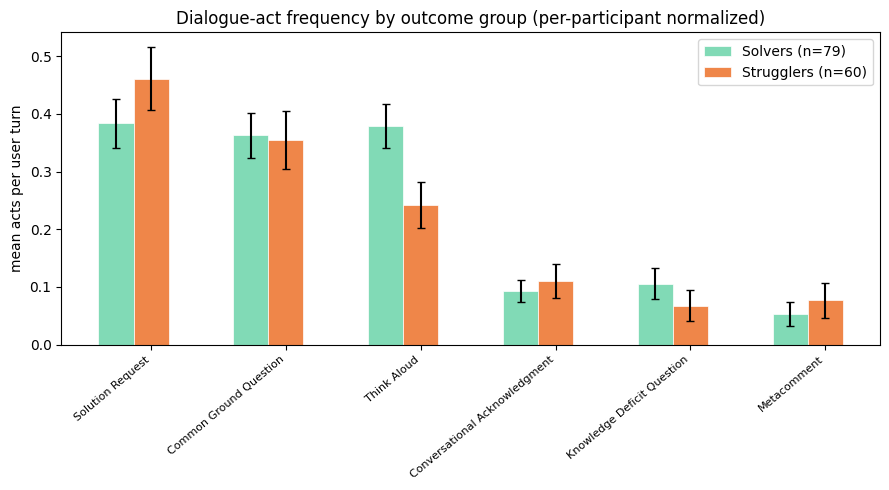

In [566]:
# Per-participant, per-turn rate of each dialogue act, averaged within group.
turns_per_pid = df.groupby("pid")["utt_ind"].nunique()          # user turns per participant
acts_df = df.dropna(subset=["utt_type"])

cnt = acts_df.groupby(["pid", "utt_type"]).size().rename("n").reset_index()
cnt["rate"] = cnt["n"] / cnt["pid"].map(turns_per_pid)

# participants x acts table of rates (0 where a participant never used that act);
# reindex over ALL pids so participants with no coded acts still count as zeros
rate_tbl = cnt.pivot_table(index="pid", columns="utt_type", values="rate", fill_value=0)
rate_tbl = rate_tbl.reindex(sorted(df["pid"].unique()), fill_value=0)
rate_tbl["outcome"] = rate_tbl.index.map(group_of)

acts_order = rate_tbl.drop(columns="outcome").sum().sort_values(ascending=False).index.tolist()
grp_mean = rate_tbl.groupby("outcome")[acts_order].mean()
grp_sem = rate_tbl.groupby("outcome")[acts_order].sem()
n_by = rate_tbl["outcome"].value_counts()

GRP = [("won", "#81dab6"), ("lost", "#ef8649")]
DISP = {"won": "Solvers", "win": "Solvers", "lost": "Strugglers"}
fig, ax = plt.subplots(figsize=(max(9, 0.9 * len(acts_order) + 3), 5))
x = np.arange(len(acts_order)); w = 0.26
for gi, (g, col) in enumerate(GRP):
    ax.bar(x + (gi - 1) * w, grp_mean.loc[g], w, yerr=grp_sem.loc[g], capsize=3,
           color=col, label=f"{DISP.get(g, g)} (n={n_by.get(g, 0)})", edgecolor="white", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(acts_order, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("mean acts per user turn")
ax.set_title("Dialogue-act frequency by outcome group (per-participant normalized)")
ax.legend(); plt.tight_layout(); plt.show()

### How far apart the two outcomes sit (dumbbell)

One row per dialogue act: a dot for **Solvers** (green, score ≥ 2) and **Strugglers** (red), each = that group's 
**mean % of a participant's turns that contain the act**, joined by a gray bar whose length is the gap. 
**Longer bar = the act separates Solvers from Strugglers more.** Sorted with the biggest separators on top 
(n per group is in the legend; treat small gaps as noise).

The denominator is **turns**, not act labels. Dividing by act labels makes the metric depend on how many labels 
a turn happened to earn — a turn carries 1–3, so saying more of anything else deflates every other act's share. 
Because a single turn can carry several acts, **these shares do not sum to 100%**.


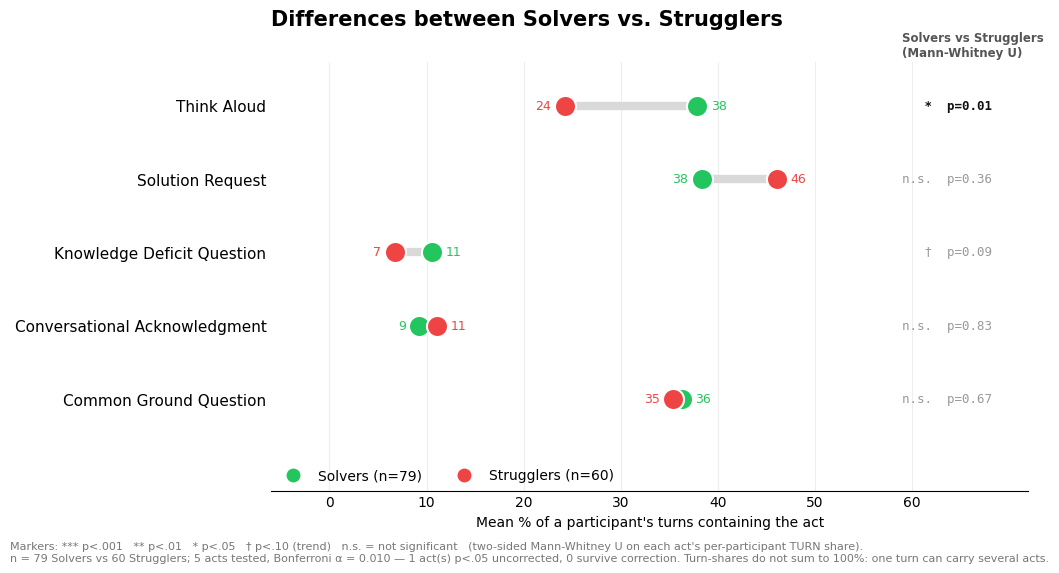

In [567]:
# Dumbbell: won vs lost separation on each dialogue act (+ significance markers).
# metric = % of a participant's TURNS that contain the act. The denominator used to be the
# participant's ACT-LABEL count, which is a labelling artefact: a turn earns 1-3 labels, so
# saying more of anything else mechanically deflates every other act's share. Turns are one
# per participant message, so they can't do that.
# NOTE: turn-shares do NOT sum to 100% across acts -- one turn can carry several acts.
# Labels sit on the OUTER side of each dot (smaller->left, larger->right) so they never
# overlap when dots are close. Right-hand column: Mann-Whitney U p-value per act + stars.
# Population is unchanged: good_pid (won, score>=2) vs bad_pid (lost) -- the original set.
# Participants who never conversed have no turns and are absent from df, so they are excluded
# here (as they always were) -- keep the OLS cell's MIN_TURNS >= 1 to match.
from scipy.stats import mannwhitneyu
import matplotlib.transforms as mtransforms

LAB = [("Solvers", good_pid, "#22c55e"), ("Strugglers", bad_pid, "#ef4444")]
acts_all = df.dropna(subset=["utt_type"])
tot = df.groupby("pid")["utt_ind"].nunique()                  # TURNS per participant
cnt = (acts_all.drop_duplicates(["pid", "utt_ind", "utt_type"])   # 1 row per (turn, act)
         .groupby(["pid", "utt_type"]).size().unstack(fill_value=0)
         .reindex(sorted(df["pid"].unique()), fill_value=0))   # = turns containing each act
share = 100 * cnt.div(tot, axis=0).fillna(0)                  # pid x act (% of that pid's TURNS)

won_ids = [p for p in good_pid if p in share.index]           # score >= 2
lost_ids = [p for p in bad_pid if p in share.index]

def gmean(pids, a):
    idx = [p for p in pids if p in share.index]
    return share.loc[idx, a].mean()

def mwu_p(a):
    _, p = mannwhitneyu(share.loc[won_ids, a].values,
                        share.loc[lost_ids, a].values, alternative="two-sided")
    return p

def sig_mark(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "†"                            # dagger = trend
    return "n.s."

acts = sorted(share.columns, key=lambda a: abs(gmean(good_pid, a) - gmean(bad_pid, a)), reverse=True)
acts.remove("Metacomment")
y = np.arange(len(acts))
PAD = 1.4                                                     # horizontal gap between dot and its label
alpha_bonf = 0.05 / len(acts)                                # multiple-comparison threshold

fig, ax = plt.subplots(figsize=(10.5, 0.7 * len(acts) + 2))
XR = max(72, share.mean().max() + 24)                        # room for the significance column
SIG_X = XR - 13                                              # left edge of the p-value column
for yi, a in zip(y, acts):
    ranked = sorted(LAB, key=lambda t: gmean(t[1], a))       # ascending by value
    (lo_lab, lo_p, lo_c), (hi_lab, hi_p, hi_c) = ranked
    lo, hi = gmean(lo_p, a), gmean(hi_p, a)
    ax.hlines(yi, lo, hi, color="#d9d9d9", lw=6, zorder=1, capstyle="round")
    for lab, pids, col in LAB:
        ax.scatter(gmean(pids, a), yi, s=230, color=col, edgecolor="white", lw=1.5, zorder=3)
    ax.text(lo - PAD, yi, f"{lo:.0f}", ha="right", va="center", fontsize=9, color=lo_c)   # smaller -> left
    ax.text(hi + PAD, yi, f"{hi:.0f}", ha="left", va="center", fontsize=9, color=hi_c)    # larger  -> right
    # significance marker (Mann-Whitney U, won vs lost turn-share)
    p = mwu_p(a)
    is_sig = p < 0.05
    ax.text(SIG_X, yi, f"{sig_mark(p):>4}  p={p:.2f}", ha="left", va="center", fontsize=9,
            family="monospace", color=("#111" if is_sig else "#999"),
            fontweight=("bold" if is_sig else "normal"))
ax.set_yticks(y); ax.set_yticklabels(acts, fontsize=11)
ax.invert_yaxis()
# reserve a blank strip under the last row for the legend -- turn-shares run higher than
# act-shares, so an in-plot legend would otherwise sit on top of the bottom row's dots
ax.set_ylim(len(acts) - 0.5 + 0.75, -0.6)
ax.set_xlim(-6, XR)
ax.set_xticks([t for t in range(0, 61, 10)])                 # ticks span the data range only
ax.set_xlabel("Mean % of a participant's turns containing the act")
ax.set_title("Differences between Solvers vs. Strugglers", fontsize=15, fontweight="bold", loc="left", pad=26)
# significance-column header (data x, axes-fraction y so it sits just above the top row)
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
ax.text(SIG_X, 1.005, "Solvers vs Strugglers\n(Mann-Whitney U)", transform=trans, ha="left", va="bottom",
        fontsize=8.5, color="#555", fontweight="bold")
ax.grid(axis="x", color="#eee", zorder=0); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)
handles = [plt.Line2D([0], [0], marker="o", ls="", ms=11, mfc=col, mec="white",
                      label=f"{lab} (n={len([p for p in pids if p in share.index])})")
           for lab, pids, col in LAB]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=10, ncol=2,
          bbox_to_anchor=(0.0, 0.0), borderaxespad=0.2)
_n_unc = sum(1 for a in acts if mwu_p(a) < 0.05)
_n_bonf = sum(1 for a in acts if mwu_p(a) < alpha_bonf)
fig.text(0.01, -0.03,
         f"Markers: *** p<.001   ** p<.01   * p<.05   † p<.10 (trend)   n.s. = not significant   "
         f"(two-sided Mann-Whitney U on each act's per-participant TURN share).\n"
         f"n = {len(won_ids)} Solvers vs {len(lost_ids)} Strugglers; {len(acts)} acts tested, "
         f"Bonferroni α = {alpha_bonf:.3f} — {_n_unc} act(s) p<.05 uncorrected, {_n_bonf} survive correction. "
         f"Turn-shares do not sum to 100%: one turn can carry several acts.",
         fontsize=8, color="#777", ha="left")
plt.tight_layout(); plt.show()


### Solvers vs Strugglers: permutation test per dialogue act

Label-permutation test on the difference in group means for each act's **% of a participant's turns containing it**, 
Solvers (score ≥ 2) vs Strugglers. Participants who used a turn but never that act count as 0%. Also reports 
Mann-Whitney U (nonparametric — safer here since shares are bounded and zero-heavy) and Cohen's d (effect size).

*Caveats:* group sizes are printed by the cell, and testing several acts means multiple comparisons — the Bonferroni 
threshold is α = 0.05 / (#variables tested). Treat as exploratory. With a median of ~2 turns per participant these 
shares are coarse, so read the gaps as directional.


In [568]:
# Permutation test (+ Mann-Whitney, Cohen's d) on per-participant TURN share, won vs lost.
# Denominator = the participant's TURNS, not their act-label count (see the dumbbell cell:
# act-shares are deflated by however many labels a turn happened to earn). This matches the
# B = Think Aloud / turns IV used in the OLS cell.
# Permutation rather than Welch's t-test: these shares are bounded, zero-heavy proportions
# from tiny per-participant turn counts (median ~2), so a label-permutation test on the mean
# difference is more defensible than a t-test (no normality assumption).
from scipy import stats

acts_all = df.dropna(subset=["utt_type"])
tot = df.groupby("pid")["utt_ind"].nunique()                  # TURNS per participant
cnt = (acts_all.drop_duplicates(["pid", "utt_ind", "utt_type"])
         .groupby(["pid", "utt_type"]).size().unstack(fill_value=0)
         .reindex(sorted(df["pid"].unique()), fill_value=0))   # = turns containing each act
share = 100 * cnt.div(tot, axis=0).fillna(0)                  # pid x act (% of that pid's TURNS)
won_ids = [p for p in good_pid if p in share.index]           # score >= 2
lost_ids = [p for p in bad_pid if p in share.index]

# Combined "reasoning" turn-share: % of a participant's turns carrying ANY of these acts.
# Computed as a UNION over turns, not a sum of per-act shares -- a turn holding two reasoning
# acts must count once, or the "share" can exceed 100%.
REASONING_ACTS = ["Think Aloud"]
_reas_turns = (acts_all[acts_all.utt_type.isin(REASONING_ACTS)]
               .groupby("pid")["utt_ind"].nunique()
               .reindex(share.index, fill_value=0))
reasoning_share = (100 * _reas_turns / tot.reindex(share.index)).fillna(0)

# Variables to test: each individual act's turn-share, plus the combined reasoning proportion.
# variables = [(a, share[a]) for a in share.columns]
variables = []
variables.append((f"Reasoning ({'+'.join(REASONING_ACTS)})", reasoning_share))

def cohend(x, z):
    nx, nz = len(x), len(z)
    sp = np.sqrt(((nx - 1) * x.var(ddof=1) + (nz - 1) * z.var(ddof=1)) / (nx + nz - 2))
    return (x.mean() - z.mean()) / sp if sp > 0 else np.nan

def perm_test(x, z, n_perm=20000, seed=0):
    """Two-sided permutation test on the difference in group means (label shuffling)."""
    obs = x.mean() - z.mean()
    pooled = np.concatenate([x, z]); nx = len(x)
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        d = perm[:nx].mean() - perm[nx:].mean()
        if abs(d) >= abs(obs) - 1e-12:
            ge += 1
    return obs, (ge + 1) / (n_perm + 1)                      # +1 = the observed labeling

rows = []
for a, series in variables:
    x, z = series.loc[won_ids].values, series.loc[lost_ids].values
    obs, p_perm = perm_test(x, z)                            # permutation (mean diff)
    _, pu = stats.mannwhitneyu(x, z, alternative="two-sided")
    rows.append((a, x.mean(), z.mean(), obs, p_perm, pu, cohend(x, z)))
rows.sort(key=lambda r: r[4])                                # by permutation p

alpha_bonf = 0.05 / len(rows)
print(f"Permutation test (mean diff, 20k shuffles) on TURN shares: "
      f"Solvers (n={len(won_ids)}) vs Strugglers (n={len(lost_ids)})   "
      f"Bonferroni alpha = {alpha_bonf:.4f}\n")
print(f"{'act':>28} {'Solv%':>6} {'Strug%':>6} {'diff':>6} {'perm_p':>7} {'MWU_p':>7} {'d':>6}")
for a, w, l, dff, p, pu, d in rows:
    star = "*" if p < alpha_bonf else ("." if p < 0.05 else " ")
    print(f"{a:>28} {w:6.1f} {l:6.1f} {dff:+6.1f} {p:7.3f} {pu:7.3f} {d:+6.2f} {star}")
print("\n  * p < Bonferroni alpha    . p < 0.05 (uncorrected)")
print("  % = share of a participant's TURNS carrying the act (turns, not act labels).")


Permutation test (mean diff, 20k shuffles) on TURN shares: Solvers (n=79) vs Strugglers (n=60)   Bonferroni alpha = 0.0500

                         act  Solv% Strug%   diff  perm_p   MWU_p      d
     Reasoning (Think Aloud)   37.9   24.3  +13.6   0.016   0.011  +0.42 *

  * p < Bonferroni alpha    . p < 0.05 (uncorrected)
  % = share of a participant's TURNS carrying the act (turns, not act labels).


In [569]:
reasoning_share

pid
p542     66.666667
p201     66.666667
p226      0.000000
p310     20.000000
p847      0.000000
                               ...    
p620    100.000000
p393      0.000000
p407     85.714286
p306    100.000000
p600      0.000000
Name: utt_ind, Length: 139, dtype: float64

# Solution Request + Reasoning CO-OCCURRENCE

In [570]:

from scipy import stats

acts_all = df.dropna(subset=["utt_type"])


In [571]:
acts_all

,pid,utt,utt_type,conf,needs_review,utt_ind,outcome
0,p201,I was thinking of putting one in 3-3,Think Aloud,1.000000,False,0,won
1,p201,it would prevent yellow and open up one opport...,Think Aloud,1.000000,False,1,won
2,p201,what is the best next move,Solution Request,1.000000,False,2,won
3,p40,Is column 2 not good? I'd put the opponent in ...,Think Aloud,1.000000,False,0,won
4,p40,Is column 2 not good? I'd put the opponent in ...,Common Ground Question,1.000000,False,0,won
...,...,...,...,...,...,...,...
524,p828,"If I add to column 2, will that reduce my poss...",Common Ground Question,1.000000,False,0,lost
525,p828,"How about column 5, then?",Common Ground Question,1.000000,False,1,lost
526,p828,"how about 4, blocking yellow's progress and ad...",Think Aloud,0.666667,False,2,lost
527,p828,"how about 4, blocking yellow's progress and ad...",Common Ground Question,1.000000,False,2,lost


In [572]:
all_pids = []
all_shares = []
for pid in acts_all["pid"].unique():
    rel_df = acts_all.loc[acts_all["pid"] == pid]
    total_utt = len(rel_df["utt_ind"].unique())
    shared_request = 0
    for uid in rel_df["utt_ind"].unique():
        curr_utt = rel_df.loc[rel_df["utt_ind"] == uid]["utt_type"].unique()
        if ("Think Aloud" in curr_utt) and "Solution Request" in curr_utt:
            shared_request += 1
    all_pids.append(pid)
    all_shares.append((shared_request / total_utt) * 100)

shared_shares = pd.Series(data=all_shares, index=all_pids)


In [573]:
won_ids = [p for p in good_pid if p in share.index]           # score >= 2
lost_ids = [p for p in bad_pid if p in share.index]

In [574]:
shared_shares

p201     0.000000
p40     0.000000
p603     0.000000
p423     0.000000
p32    66.666667
                              ...    
p465     0.000000
p659    50.000000
p292     0.000000
p828     0.000000
p95     0.000000
Length: 139, dtype: float64

In [575]:
# Variables to test: each individual act's turn-share, plus the combined reasoning proportion.
# variables = [(a, share[a]) for a in share.columns]
variables = []
variables.append((f"Shared Request", shared_shares))

def cohend(x, z):
    nx, nz = len(x), len(z)
    sp = np.sqrt(((nx - 1) * x.var(ddof=1) + (nz - 1) * z.var(ddof=1)) / (nx + nz - 2))
    return (x.mean() - z.mean()) / sp if sp > 0 else np.nan

def perm_test(x, z, n_perm=20000, seed=0):
    """Two-sided permutation test on the difference in group means (label shuffling)."""
    obs = x.mean() - z.mean()
    pooled = np.concatenate([x, z]); nx = len(x)
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        d = perm[:nx].mean() - perm[nx:].mean()
        if abs(d) >= abs(obs) - 1e-12:
            ge += 1
    return obs, (ge + 1) / (n_perm + 1)                      # +1 = the observed labeling

rows = []
for a, series in variables:
    x, z = series.loc[won_ids].values, series.loc[lost_ids].values
    obs, p_perm = perm_test(x, z)                            # permutation (mean diff)
    _, pu = stats.mannwhitneyu(x, z, alternative="two-sided")
    rows.append((a, x.mean(), z.mean(), obs, p_perm, pu, cohend(x, z)))
rows.sort(key=lambda r: r[4])                                # by permutation p

alpha_bonf = 0.05 / len(rows)
print(f"Permutation test (mean diff, 20k shuffles) on TURN shares: "
      f"Solvers (n={len(won_ids)}) vs Strugglers (n={len(lost_ids)})   "
      f"Bonferroni alpha = {alpha_bonf:.4f}\n")
print(f"{'act':>28} {'Solv%':>6} {'Strug%':>6} {'diff':>6} {'perm_p':>7} {'MWU_p':>7} {'d':>6}")
for a, w, l, dff, p, pu, d in rows:
    star = "*" if p < alpha_bonf else ("." if p < 0.05 else " ")
    print(f"{a:>28} {w:6.1f} {l:6.1f} {dff:+6.1f} {p:7.3f} {pu:7.3f} {d:+6.2f} {star}")
print("\n  * p < Bonferroni alpha    . p < 0.05 (uncorrected)")
print("  % = share of a participant's TURNS carrying the act (turns, not act labels).")

Permutation test (mean diff, 20k shuffles) on TURN shares: Solvers (n=79) vs Strugglers (n=60)   Bonferroni alpha = 0.0500

                         act  Solv% Strug%   diff  perm_p   MWU_p      d
              Shared Request    8.6    1.4   +7.2   0.011   0.005  +0.44 *

  * p < Bonferroni alpha    . p < 0.05 (uncorrected)
  % = share of a participant's TURNS carrying the act (turns, not act labels).


In [576]:
df.to_csv("participant_utterances.csv", index=False)

# AI-assistant rating by outcome group (Solvers / Strugglers)

From `assistant_helpfulness.csv` — the post-round survey on the AI assistant. Two items on a 5-point Likert (strongly disagree=1 … strongly agree=5):

- **consistent-with-intent** — "responses were consistent with the intentions of my questions"
- **easy-to-use** — "the AI assistant was easy to use"

Each participant is tagged with their Round-2 outcome label (Solvers / Strugglers). Duplicate submissions are resolved to the participant's **first** (Round-1) response; respondents not among our 35 both-round completers are unlabeled and excluded from group means.

survey respondents: 90   labeled (in our 35 completers): 81
labeled completers with NO survey row (84): 53987712[Solvers], 558955eb[Solvers], 56f699e8[Solvers], 57c426fa[Strugglers], 57d1d045[Solvers], 57d74ff1[Solvers], 594a969d[Solvers], 596d1cdf[Solvers], 59e1e960[Solvers], 59f0be85[Solvers], 5a068d5b[Strugglers], 5a5bd24b[Strugglers], 5bc0ac84[Solvers], 5bed01c8[Strugglers], 5c5ca0ce[Solvers], 5c608863[Strugglers], 5c62de3f[Strugglers], 5c6709ab[Strugglers], 5c922408[Solvers], 5ca5fb08[Solvers], 5cf29f37[Strugglers], 5d464c8a[Solvers], 5d66b4f5[Strugglers], 5d7ebf9e[Strugglers], 5db303e4[Strugglers], 5e0413f6[Solvers], 5e0f5a17[Solvers], 5e573ce5[Strugglers], 5ea2e082[Solvers], 5ee5e3b0[Strugglers], 5f2150b3[Strugglers], 5f818c9c[Strugglers], 6002ae1e[Solvers], 60147f79[Strugglers], 601b0712[Solvers], 604516f2[Solvers], 606e27e9[Solvers], 60e49deb[Solvers], 6140ef8d[Strugglers], 6148bfc3[Solvers], 61545686[Strugglers], 6154973c[Solvers], 6234b0c2[Solvers], 628eada3[Solvers], 62a15d

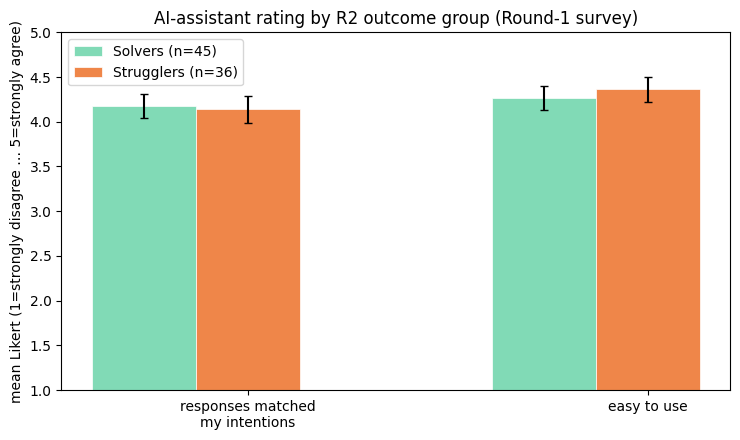

In [577]:
# --- Join assistant_helpfulness.csv with Solvers/Strugglers labels ---
import csv

LIKERT = {"strongly disagree": 1, "disagree": 2, "neutral": 3, "agree": 4, "strongly agree": 5}
GROUP_OF = {**{p: "won" for p in good_pid}, **{p: "win" for p in win_pid}, **{p: "lost" for p in bad_pid}}
DISP = {"won": "Solvers", "win": "Solvers", "lost": "Strugglers"}

rows = list(csv.DictReader(open("assistant_helpfulness.csv")))
cols = list(rows[0].keys())
pid_col, intent_col, ease_col = cols[1], cols[2], cols[3]   # ID, "consistent with intentions", "easy to use"

# one record per participant = their FIRST (Round-1) submission
per_pid = {}
for r in rows:
    pid = r[pid_col].strip()
    if pid in per_pid:
        continue
    per_pid[pid] = {
        "intent": LIKERT.get(r[intent_col].strip().lower()),
        "ease":   LIKERT.get(r[ease_col].strip().lower()),
        "group":  GROUP_OF.get(pid),
    }

labeled = {p: v for p, v in per_pid.items() if v["group"]}
missing = sorted(set(GROUP_OF) - set(per_pid))          # labeled completers with no survey row
print(f"survey respondents: {len(per_pid)}   labeled (in our 35 completers): {len(labeled)}")
if missing:
    print(f"labeled completers with NO survey row ({len(missing)}): "
          + ", ".join(f"{p[:8]}[{DISP.get(GROUP_OF[p], GROUP_OF[p])}]" for p in missing))

# per-participant labeled table
print(f"\n{'participant':>12} {'group':>11} {'intent':>7} {'ease':>5}")
for pid, v in sorted(labeled.items(), key=lambda kv: (kv[1]["group"], kv[0])):
    print(f"{pid[:12]:>12} {DISP.get(v['group'], v['group']):>11} {str(v['intent']):>7} {str(v['ease']):>5}")

# group means + plot
GRP = [("won", "#81dab6"), ("lost", "#ef8649")]
METRICS = [("intent", "responses matched\nmy intentions"), ("ease", "easy to use")]
print()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(METRICS)); w = 0.26
for gi, (grp, col) in enumerate(GRP):
    vs = [v for v in labeled.values() if v["group"] == grp]
    means = [np.mean([v[m] for v in vs if v[m] is not None]) for m, _ in METRICS]
    sems = [np.std([v[m] for v in vs if v[m] is not None]) / np.sqrt(sum(v[m] is not None for v in vs))
            for m, _ in METRICS]
    ax.bar(x + (gi - 1) * w, means, w, yerr=sems, capsize=3, color=col,
           label=f"{DISP.get(grp, grp)} (n={len(vs)})", edgecolor="white", lw=0.5)
    print(f"{DISP.get(grp, grp):>11} (n={len(vs)}):  intent {means[0]:.2f}   ease {means[1]:.2f}")
ax.set_xticks(x); ax.set_xticklabels([lbl for _, lbl in METRICS])
ax.set_ylim(1, 5); ax.set_ylabel("mean Likert (1=strongly disagree … 5=strongly agree)")
ax.set_title("AI-assistant rating by R2 outcome group (Round-1 survey)")
ax.legend(); plt.tight_layout(); plt.show()

# Time per Puzzle

In [578]:
import os
import datetime

def _ts(s):
    return datetime.datetime.fromisoformat(s)

def measure_time(pids):
    times = []
    for pid in pids:
        moves_f  = RECORDINGS_BASE / pid / "moves_p15.jsonl"
        prompt_f = RECORDINGS_BASE / pid / "prompt_task.json"
        if os.path.exists(moves_f) and os.path.exists(prompt_f):
            lines = [json.loads(l) for l in open(moves_f) if l.strip()]
            start = _ts(json.load(open(prompt_f))["submitted_at"])   # approx puzzle start
            end   = _ts(lines[-1]["ts"])                             # last move
            times.append((end - start).total_seconds())
        else:
            times.append(None)
    times = [x for x in times if x is not None]
    return np.mean(times), np.median(times), np.std(times),  max(times), min(times)

print("P1 SOLVERS === ", measure_time(good_pid))
print("P1 STRUGGLERS ===", measure_time(bad_pid))


P1 SOLVERS ===  (np.float64(207.4088998936171), np.float64(188.50496399999997), np.float64(132.42526723982505), 850.43089, 28.804288)
P1 STRUGGLERS === (np.float64(215.28056415492955), np.float64(184.388287), np.float64(139.5140627730762), 783.032093, -248.839773)


In [579]:
import os
import datetime

def _ts(s):
    return datetime.datetime.fromisoformat(s)

def measure_time(pids):
    times = []
    for pid in pids:
        moves_f  = RECORDINGS_BASE / pid / "moves_pw4p6.jsonl"
        prompt_f = RECORDINGS_BASE / pid / "post_survey_p15.json"
        if os.path.exists(moves_f) and os.path.exists(prompt_f):
            lines = [json.loads(l) for l in open(moves_f) if l.strip()]
            start = _ts(json.load(open(prompt_f))["submitted_at"])   # approx puzzle start
            end   = _ts(lines[-1]["ts"])                             # last move
            times.append((end - start).total_seconds())
        else:
            times.append(None)
    times = [x for x in times if x is not None]
    return np.mean(times), np.median(times), np.std(times),  max(times), min(times)

print("P2 SOLVERS === ", measure_time(good_pid))
print("P2 STRUGGLERS === ", measure_time(bad_pid))

P2 SOLVERS ===  (np.float64(51.4617225638298), np.float64(45.9313415), np.float64(23.42070450785144), 148.704112, 12.893085)
P2 STRUGGLERS ===  (np.float64(62.31554015492958), np.float64(55.174737), np.float64(31.859106892771266), 155.514216, 11.81713)


Solvers    Round 1 (p15, with AI) n=94  mean= 207.4s  median= 188.5s  sd=132.4s
Strugglers Round 1 (p15, with AI) n=70  mean= 221.9s  median= 185.8s  sd=128.9s  [dropped 1 non-positive]
Solvers    Round 2 (w4p6, solo)   n=94  mean=  51.5s  median=  45.9s  sd= 23.4s
Strugglers Round 2 (w4p6, solo)   n=71  mean=  62.3s  median=  55.2s  sd= 31.9s


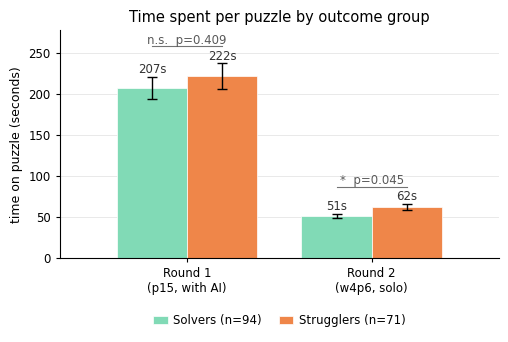

In [580]:
# --- Time spent per puzzle: Solvers vs Strugglers (grouped bars) ---
# Same start/end convention as the two cells above: start = the survey submitted right
# before the puzzle (prompt_task.json -> R1 p15, post_survey_p15.json -> R2 pw4p6),
# end = the timestamp of the participant's last move.
# NOTE: a few R1 records have that survey stamped AFTER the first move (flow/clock
# artifact -> negative duration; the R1 min above is -249s). Those are dropped here and
# the count is printed, so they don't silently drag the means down.
from scipy.stats import mannwhitneyu

PUZZLES = [("Round 1\n(p15, with AI)", "moves_p15.jsonl",   "prompt_task.json"),
           ("Round 2\n(w4p6, solo)",   "moves_pw4p6.jsonl", "post_survey_p15.json")]
GRP_T = [("Solvers", good_pid, "#81dab6"), ("Strugglers", bad_pid, "#ef8649")]

def times_list(pids, moves_name, start_name):
    """Per-participant seconds on a puzzle; returns (valid_times, n_dropped)."""
    out, dropped = [], 0
    for pid in pids:
        moves_f, start_f = RECORDINGS_BASE / pid / moves_name, RECORDINGS_BASE / pid / start_name
        if not (moves_f.exists() and start_f.exists()):
            continue
        lines = [json.loads(l) for l in open(moves_f) if l.strip()]
        if not lines:
            continue
        secs = (_ts(lines[-1]["ts"]) - _ts(json.load(open(start_f))["submitted_at"])).total_seconds()
        if secs <= 0:
            dropped += 1
        else:
            out.append(secs)
    return out, dropped

# Collect every number first, so the y-axis is sized from what actually gets DRAWN
# (bar tops + brackets) rather than from raw per-participant maxima -- that mismatch is
# what left ~75s of dead headroom and floated the Round-2 bracket below its own bars.
stats, pvals = {}, []
for pi, (plab, mv, st) in enumerate(PUZZLES):
    for gi, (nm, pids_, _) in enumerate(GRP_T):
        t, drop = times_list(pids_, mv, st)
        stats[gi, pi] = (np.mean(t), np.std(t) / np.sqrt(len(t)), len(t))
        print(f"{nm:<10} {plab.replace(chr(10), ' '):<22} n={len(t):2d}  mean={np.mean(t):6.1f}s  "
              f"median={np.median(t):6.1f}s  sd={np.std(t):5.1f}s"
              + (f"  [dropped {drop} non-positive]" if drop else ""))
    pvals.append(mannwhitneyu(times_list(good_pid, mv, st)[0],
                              times_list(bad_pid, mv, st)[0], alternative="two-sided").pvalue)

W = 0.38                                             # bar width; pair spans 2W of a 1.0 step
tops = {(gi, pi): m + s for (gi, pi), (m, s, _) in stats.items()}
PAD = 0.055 * max(tops.values())                     # one clearance unit for labels/brackets

fig, ax = plt.subplots(figsize=(5.0, 3.4))
for gi, (nm, pids_, col) in enumerate(GRP_T):
    for pi in range(len(PUZZLES)):
        x = pi + (gi - 0.5) * W
        mean, sem, n = stats[gi, pi]
        ax.bar(x, mean, W, yerr=sem, capsize=3.5, color=col, edgecolor="white", lw=0.5,
               error_kw=dict(lw=1.0), label=f"{nm} (n={len(pids_)})" if pi == 0 else None)
        ax.text(x, mean + sem + 0.35 * PAD, f"{mean:.0f}s", ha="center", fontsize=8.5, color="0.2")

# Mann-Whitney U per puzzle, bracket anchored just above THAT pair's taller bar
ytop = 0
for pi, p in enumerate(pvals):
    y = max(tops[0, pi], tops[1, pi]) + 1.6 * PAD
    ax.plot([pi - W / 2, pi + W / 2], [y, y], color="0.45", lw=0.8)
    stars = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
    ax.text(pi, y + 0.25 * PAD, f"{stars}  p={p:.3f}", ha="center", fontsize=8.5, color="0.35")
    ytop = max(ytop, y + 1.5 * PAD)                  # room for the annotation text itself

ax.set_xticks(range(len(PUZZLES)))
ax.set_xticklabels([p[0] for p in PUZZLES], fontsize=9)
ax.set_xlim(-0.5 - W / 2, len(PUZZLES) - 1 + 0.5 + W / 2)   # trim the outer margins
ax.set_ylim(0, ytop)
ax.set_ylabel("time on puzzle (seconds)", fontsize=9)
ax.set_title("Time spent per puzzle by outcome group", fontsize=10.5)
ax.tick_params(labelsize=8.5, length=3)
ax.grid(axis="y", lw=0.4, color="0.85"); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
# Legend below the axis: the upper-right lane it used to sit in was the dead space.
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper center",
          bbox_to_anchor=(0.5, -0.20), columnspacing=1.4, handlelength=1.2, handletextpad=0.5)
fig.tight_layout(pad=0.4); plt.show()


## OLS: R1 reasoning-act engagement → R2 performance

Regress each R2 outcome on the share of a participant's R1 dialogue acts that are *reasoning* acts (Common Ground Question + Think Aloud + Knowledge-Deficit Question). Exploratory / single-predictor; IV is from the AI-assisted R1 conversation, DV from the unassisted R2.

In [581]:
# --- OLS: R1 reasoning-act engagement -> flat R2 score, by R1 outcome band ---
# IV  : share of a participant's R1 dialogue acts that are "reasoning" acts (REASONING_ACTS).
# COV : genai -- self-reported GenAI usage frequency, ordinal 0..7 from demographics.json
#       (GENAI_BINARY switches to the >= few_times_week split the demographic cells use).
# GRP : r1_group -- R1 outcome band, 0 = score <=1, 1 = score == 2, 2 = score >= 3.
# DV  : flat R2 score only.
# Pooled first -- M1 reasoning only (the pre-specified model) | M2 + genai | M3 + genai +
# R1 band as a level shift | M4 reasoning x R1 band, F-test on the interaction = "does the
# slope differ across bands?" -- then the same reasoning + genai fit inside each band.
# Everything past M1 is exploratory, and band 0 is thin (n=15), so read it as descriptive.
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats as _stats

# REASONING_ACTS = ["Common Ground Question", "Think Aloud", "Knowledge Deficit Question"]
REASONING_ACTS = ["Think Aloud"]
SHOW_SUMMARY = True                                            # print fit.summary() for M3
GENAI_BINARY = True                                            # True -> 1 if >= few_times_week


# per-participant reasoning-act share (proportion of that participant's acts)
_acts = df.dropna(subset=["utt_type"])
_tot = _acts.groupby("pid").size()
_cnt = (_acts.groupby(["pid", "utt_type"]).size().unstack(fill_value=0)
             .reindex(sorted(df["pid"].unique()), fill_value=0))
_share = _cnt.div(_tot, axis=0).fillna(0)                       # proportion in [0, 1]
reasoning_prop = _share[[a for a in REASONING_ACTS if a in _share.columns]].sum(axis=1)

GENAI_USAGE_OPTIONS = {"never": 0, "less_than_monthly": 1, "about_monthly": 2,
                       "few_times_month": 3, "weekly": 4, "few_times_week": 5,
                       "daily": 6, "several_times_day": 7}
R1_LABEL = {0: "R1 score <= 1", 1: "R1 score == 2", 2: "R1 score >= 3"}

# one row per participant: IV, covariate, band, and the flat R2 score (gradable R2 required)
rows = []
for pid in reasoning_prop.index:
    f1, f2 = RECORDINGS_BASE / pid / score_r1, RECORDINGS_BASE / pid / score_r2
    fd = RECORDINGS_BASE / pid / "demographics.json"
    if not (f1.exists() and f2.exists()):
        continue
    j2 = json.load(open(f2))
    if not j2.get("gradable") or j2.get("score_selectivity_raw") is None:
        continue
    sc1 = json.load(open(f1)).get("score")
    if sc1 is None:
        continue
    gv = json.load(open(fd)).get("genai_usage") if fd.exists() else None
    g = float(GENAI_USAGE_OPTIONS.get(gv, np.nan))              # nan when the item is blank
    if GENAI_BINARY and not np.isnan(g):
        g = float(g >= GENAI_USAGE_OPTIONS["few_times_week"])
    if sc1 <= 1:
        group_r1 = 0
    elif sc1 == 2:
        group_r1 = 1
    else:
        group_r1 = 2
    if pid in reasoning_prop:
        rows.append(dict(pid=pid, reasoning=float(reasoning_prop[pid]), genai=g, r1_score=sc1,
                        r1_group=group_r1,
                        y=j2.get("flat_score")))
    else:
        rows.append(dict(pid=pid, reasoning=0, genai=g, r1_score=sc1,
                                r1_group=group_r1,
                                y=j2.get("flat_score")))
mdl = pd.DataFrame(rows).set_index("pid")

print(f"analysis sample: n={len(mdl)}   missing GenAI item: {int(mdl['genai'].isna().sum())} "
      f"(those rows drop out of every model that includes genai)")
print(f"reasoning share ({' + '.join(REASONING_ACTS)}): mean={mdl.reasoning.mean():.3f} "
      f"sd={mdl.reasoning.std(ddof=1):.3f}   genai: mean={mdl.genai.mean():.2f} "
      f"sd={mdl.genai.std(ddof=1):.2f}" + ("  [binary >= few/wk]" if GENAI_BINARY else "  [0-7 ordinal]"))
print(f"\n  {'band':<14} {'n':>3}   {'reasoning':>18}   {'genai':>11}   {'flat R2':>11}")
for _g, _lab in R1_LABEL.items():
    _s = mdl[mdl.r1_group == _g]
    print(f"  {_lab:<14} {len(_s):>3}   {_s.reasoning.mean():>8.3f} +-{_s.reasoning.std(ddof=1):6.3f}   "
          f"{_s.genai.mean():>4.2f} +-{_s.genai.std(ddof=1):4.2f}   "
          f"{_s.y.mean():>4.2f} +-{_s.y.std(ddof=1):4.2f}")

def _row(label, fit):
    """One line: the reasoning slope, the genai slope if the model has one, and fit stats."""
    b, se = fit.params.get("reasoning", np.nan), fit.bse.get("reasoning", np.nan)
    t, p = fit.tvalues.get("reasoning", np.nan), fit.pvalues.get("reasoning", np.nan)
    bg, pg = fit.params.get("genai", np.nan), fit.pvalues.get("genai", np.nan)
    gtxt = f"{'-':>7} {'-':>7}" if np.isnan(bg) else f"{bg:+7.3f} {pg:7.4f}"
    star = " *" if p < 0.05 else ("  ." if p < 0.10 else "")
    print(f"  {label:<28} {int(fit.nobs):>4} {b:+8.3f} {se:6.3f} {t:6.2f} {p:7.4f} "
          f"{gtxt} {fit.rsquared:6.3f} {fit.rsquared_adj:6.3f}{star}")

r, rp = _stats.pearsonr(mdl.reasoning, mdl.y); rho, rhop = _stats.spearmanr(mdl.reasoning, mdl.y)
print(f"\nflat R2 score ~ reasoning share   (bivariate: Pearson r={r:+.3f} p={rp:.4f} | "
      f"Spearman rho={rho:+.3f} p={rhop:.4f})")
print(f"  {'model':<28} {'n':>4} {'b_reason':>8} {'SE':>6} {'t':>6} {'p':>7} "
      f"{'b_genai':>7} {'p_genai':>7} {'R2':>6} {'adjR2':>6}")
_row("M1  reasoning", smf.ols("y ~ reasoning", mdl).fit())
_row("M2  + genai", smf.ols("y ~ reasoning + genai", mdl).fit())
m3 = smf.ols("y ~ reasoning + genai + C(r1_group)", mdl).fit()
_row("M3  + genai + R1 band", m3)
m4 = smf.ols("y ~ reasoning * C(r1_group) + genai", mdl).fit()
_ix = [t_ for t_ in m4.params.index if t_.startswith("reasoning:")]
ft = m4.f_test(", ".join(f"{t_} = 0" for t_ in _ix))
print(f"  {'M4  reasoning x R1 band':<28} {int(m4.nobs):>4}   interaction "
      f"F({int(ft.df_num)},{int(ft.df_denom)})={float(np.squeeze(ft.fvalue)):.2f}, "
      f"p={float(np.squeeze(ft.pvalue)):.4f}"
      f"{'  *' if float(np.squeeze(ft.pvalue)) < 0.05 else ''}")

print(f"\n  -- within band: y ~ reasoning + genai, fit separately --")
for _g, _lab in R1_LABEL.items():
    sub = mdl[mdl.r1_group == _g].dropna(subset=["y", "reasoning", "genai"])
    if len(sub) < 8 or sub.genai.nunique() < 2:
        print(f"  {_lab:<28} {len(sub):>4}   too few / no genai variance -- skipped")
        continue
    _row(_lab, smf.ols("y ~ reasoning + genai", sub).fit())
    sr, srp = _stats.spearmanr(sub.reasoning, sub.y)
    print(f"  {'':<28} {'':>4}   Spearman rho={sr:+.3f} p={srp:.4f}")
if SHOW_SUMMARY:
    print(f"\n--- M3 ---\n{m3.summary()}\n")

print("\n  * p<0.05   . p<0.10   |  IV + covariates from R1 (AI-assisted), DV from unassisted R2")
print("  M1 is the pre-specified model; M2-M4 and the within-band fits are exploratory.")
print("  M4's interaction test is the formal check on whether the within-band slopes differ.")

analysis sample: n=139   missing GenAI item: 0 (those rows drop out of every model that includes genai)
reasoning share (Think Aloud): mean=0.214 sd=0.218   genai: mean=0.66 sd=0.47  [binary >= few/wk]

  band             n            reasoning         genai       flat R2
  R1 score <= 1   17      0.263 +- 0.323   0.71 +-0.47   1.29 +-0.92
  R1 score == 2   68      0.220 +- 0.211   0.65 +-0.48   1.62 +-0.95
  R1 score >= 3   54      0.190 +- 0.186   0.67 +-0.48   1.59 +-0.90

flat R2 score ~ reasoning share   (bivariate: Pearson r=+0.172 p=0.0435 | Spearman rho=+0.185 p=0.0295)
  model                           n b_reason     SE      t       p b_genai p_genai     R2  adjR2
  M1  reasoning                 139   +0.728  0.357   2.04  0.0435       -       -  0.029  0.022 *
  M2  + genai                   139   +0.832  0.351   2.37  0.0194  -0.437  0.0077  0.079  0.065 *
  M3  + genai + R1 band         139   +0.875  0.353   2.48  0.0145  -0.431  0.0085  0.094  0.066 *
  M4  reasoning x R1 

### Ordinal logit: R1 reasoning engagement → R2 transfer

`flat_score` is the number of optimal moves out of 3 — **discrete, ordered, and capped**. A Gaussian OLS 
is the wrong likelihood for it: it places probability on impossible values (2.4 optimal moves) and assumes 
constant variance when the spread is mechanically largest mid-scale. This cell fits a **proportional-odds 
ordinal logit** instead.

Ordinal rather than binomial(n=3): the two fit equally well (AIC tie, both ≈358.7 vs 397.1 for Poisson), but 
binomial additionally assumes the three moves are exchangeable Bernoulli trials. They aren't — Connect Four 
moves are sequential and dependent — so the ordinal model rests on the weaker assumption. Both are reported 
in the diagnostics block, along with a proportional-odds check.

Coefficients are **log-odds of landing in a higher outcome category per 1 SD of the IV**; `OR = exp(b)`. 
R1 performance enters as an **ordinal covariate** (linear in the 0–3 score) rather than as bands — it's a 
covariate, not a stratifier, and the slope never varied across it. `MIN_TURNS = 1` excludes participants who 
never conversed, whose turn-share is `0/0` (undefined, not zero); the two-part check at the end confirms that 
exclusion isn't hiding an effect.


In [591]:
# --- Ordinal logit: R1 reasoning engagement -> R2 optimal-move count ---
# DV = flat_score, the number of optimal moves out of 3 graded R2 moves. It is discrete,
# ordered, and has a hard ceiling, so a Gaussian OLS is the wrong likelihood (it puts mass on
# impossible values like 2.4 and assumes constant variance when spread is largest mid-scale).
# Model: proportional-odds ORDINAL LOGIT. It assumes only that 0 < 1 < 2 < 3 are ordered.
# A binomial(n=3) would fit about equally well (AIC tie) but additionally assumes the three
# moves are exchangeable Bernoulli trials -- they are not, Connect Four moves are sequential
# and dependent -- so the ordinal model is the weaker, safer assumption.
# Coefficients are log-odds of landing in a HIGHER outcome category, per 1 SD of the IV;
# exp(b) is the odds ratio. The proportional-odds assumption is checked at the bottom.
#
# IVs (all turn-denominated -- see the dumbbell cell for why turns beat act labels):
#   B = share of R1 TURNS containing Think Aloud                     <- primary
#   A = Think Aloud / ACT LABELS                                     <- old cell-48 spec
#   F = share of turns containing Think Aloud | Common Ground Q | Knowledge Deficit Q
# R1 performance enters as an ORDINAL covariate (linear in the 0-3 score): it respects the
# ordering and costs 1 df, and the polynomial check showed no curvature to justify more.
# Bands are gone -- R1 is a covariate, not a stratifier; the slope never varied across it.
# MIN_TURNS=1 drops participants who never conversed: their turn-share is 0/0, undefined
# rather than zero. Whether someone engaged at all is a separate (null) question -- see the
# two-part model at the end.
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy import stats as _stats
import warnings

MIN_TURNS = 1
BATCH_CUTOFF = "2026-08-03"           # R1 submissions on/after this date = newest wave
REAS_SET = ["Think Aloud", "Common Ground Question", "Knowledge Deficit Question"]
IVS = [("B", "Think Aloud / turns  [primary]"),
       ("A", "Think Aloud / act labels  [old cell-48 spec]"),
       ("F", "reasoning / turns  [wider construct]")]
GENAI_OPTS = {"never": 0, "less_than_monthly": 1, "about_monthly": 2, "few_times_month": 3,
              "weekly": 4, "few_times_week": 5, "daily": 6, "several_times_day": 7}
GENAI_BINARY = True

# ---- per-participant IVs off the long act dataframe (utt_ind identifies the turn) ---------
_t = df.groupby("pid")["utt_ind"].nunique().rename("n_turns")
_coded = df.dropna(subset=["utt_type"])                       # act-less turns are None rows
_acts_pid = _coded.groupby("pid").size().reindex(_t.index, fill_value=0)
_ta_acts = _coded[_coded.utt_type == "Think Aloud"].groupby("pid").size().reindex(_t.index, fill_value=0)
_ta_turns = (_coded[_coded.utt_type == "Think Aloud"].groupby("pid")["utt_ind"].nunique()
             .reindex(_t.index, fill_value=0))
_re_turns = (_coded[_coded.utt_type.isin(REAS_SET)].groupby("pid")["utt_ind"].nunique()
             .reindex(_t.index, fill_value=0))
IV = pd.DataFrame({"n_turns": _t, "A": _ta_acts / _acts_pid.replace(0, np.nan),
                   "B": _ta_turns / _t, "F": _re_turns / _t}).fillna(0.0)

# ---- model frame -------------------------------------------------------------------------
rows = []
for pid in sorted(set(good_pid) | set(bad_pid)):
    f1, f2 = RECORDINGS_BASE / pid / score_r1, RECORDINGS_BASE / pid / score_r2
    if not (f1.exists() and f2.exists()):
        continue
    j2 = json.load(open(f2))
    if not j2.get("gradable") or j2.get("flat_score") is None:
        continue                                              # ungradable / unscored R2
    j1 = json.load(open(f1))
    if j1.get("score") is None:
        continue
    fd = RECORDINGS_BASE / pid / "demographics.json"
    gv = json.load(open(fd)).get("genai_usage") if fd.exists() else None
    g = float(GENAI_OPTS.get(gv, np.nan))
    if GENAI_BINARY and not np.isnan(g):
        g = float(g >= GENAI_OPTS["few_times_week"])
    r = dict(pid=pid, genai=g, r1_score=float(j1["score"]), y=int(j2["flat_score"]),
             new_wave=float((j1.get("submitted_at") or "")[:10] >= BATCH_CUTOFF))
    r.update(IV.loc[pid, ["A", "B", "F", "n_turns"]].to_dict() if pid in IV.index
             else dict(A=0.0, B=0.0, F=0.0, n_turns=0))
    rows.append(r)
M = pd.DataFrame(rows).set_index("pid")
n_all = len(M)
M = M[M.n_turns >= MIN_TURNS].dropna(subset=["genai", "y"]).copy()

# ---- fitting helpers ----------------------------------------------------------------------
def ordfit(rhs, frame):
    """Proportional-odds ordinal logit. No intercept: the cutpoints absorb it."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return OrderedModel.from_formula(f"y ~ 0 + {rhs}", frame,
                                         distr="logit").fit(method="bfgs", disp=False)

def lr_test(full, restricted, frame):
    """Likelihood-ratio test. Used instead of f_test: the cutpoint parameters make Wald
    constraints on this model awkward, and LR is the standard test for ordinal fits."""
    a, b = ordfit(full, frame), ordfit(restricted, frame)
    stat = 2 * (a.llf - b.llf)
    dfree = len(a.params) - len(b.params)
    return stat, dfree, _stats.chi2.sf(stat, dfree)

with warnings.catch_warnings():                     # cutpoints-only null, for McFadden pseudo-R2
    warnings.simplefilter("ignore")
    _null = OrderedModel(M.y, np.empty((len(M), 0)), distr="logit").fit(method="bfgs", disp=False)

def _row(label, fit, subset=False):
    """subset=True suppresses pseudo-R2: the null model is fit on the full sample, so the
    ratio is not meaningful for a restricted one."""
    b, se = fit.params["iv"], fit.bse["iv"]
    z, p = fit.tvalues["iv"], fit.pvalues["iv"]
    bg = fit.params.get("genai", np.nan); pg = fit.pvalues.get("genai", np.nan)
    gtxt = f"{'-':>7} {'-':>7}" if np.isnan(bg) else f"{bg:+7.3f} {pg:7.4f}"
    star = " *" if p < 0.05 else ("  ." if p < 0.10 else "")
    pr2 = f"{'':>6}" if subset else f"{1 - fit.llf / _null.llf:6.3f}"
    print(f"  {label:<30} {int(fit.nobs):>4} {b:+8.3f} {se:6.3f} {z:6.2f} {p:7.4f} "
          f"{gtxt} {np.exp(b):6.3f} {pr2}{star}")

print(f"analysis sample: n={len(M)} of {n_all}   MIN_TURNS={MIN_TURNS} "
      f"(dropped {n_all - len(M)}: never conversed or missing GenAI)   "
      f"newest wave: n={int(M.new_wave.sum())}")
print(f"DV = optimal moves out of 3: {dict(M.y.value_counts().sort_index())}")
print(f"  {'IV':<3} {'mean':>6} {'sd':>6} {'%zero':>7} {'r(n_turns)':>11}")
for c, _ in IVS:
    print(f"  {c:<3} {M[c].mean():>6.3f} {M[c].std(ddof=1):>6.3f} {(M[c] == 0).mean():>6.1%} "
          f"{M[c].corr(M.n_turns):>+11.3f}")

for c, desc in IVS:
    d = M.assign(iv=(M[c] - M[c].mean()) / M[c].std(ddof=1))   # standardized -> b is per SD
    print(f"\n{'=' * 104}\nIV = {c}:  {desc}      (log-odds per 1 SD; OR = exp(b))")
    rho, rhop = _stats.spearmanr(d.iv, d.y)
    print(f"  bivariate Spearman rho={rho:+.3f} p={rhop:.4f}")
    print(f"  {'model':<30} {'n':>4} {'b_iv':>8} {'SE':>6} {'z':>6} {'p':>7} "
          f"{'b_genai':>7} {'p_genai':>7} {'OR':>6} {'pR2':>6}")
    _row("M1  iv", ordfit("iv", d))
    _row("M2  + genai", ordfit("iv + genai", d))
    m3 = ordfit("iv + genai + r1_score", d)
    _row("M3  + genai + R1 score (ord.)", m3)
    _p3 = m3.pvalues["r1_score"]
    print(f"      R1 score covariate, per +1 optimal move: b={m3.params['r1_score']:+.3f} "
          f"(SE {m3.bse['r1_score']:.3f}, p={_p3:.4f})"
          f"{'  *' if _p3 < 0.05 else '   n.s. - R1 performance does not shift R2'}")
    _s, _df, _p = lr_test("iv * r1_score + genai", "iv + r1_score + genai", d)
    print(f"  {'M4  iv x R1 score (moderation)':<30} {int(m3.nobs):>4}   "
          f"LR chi2({_df})={_s:.3f}, p={_p:.4f}"
          f"{'  *' if _p < 0.05 else '   (slope does NOT vary with R1)'}")
    print("  -- robustness (M3 spec) --")
    for lab, sub in [("n_turns >= 2", d[d.n_turns >= 2]), ("n_turns >= 3", d[d.n_turns >= 3]),
                     ("old batches", d[d.new_wave == 0]), ("newest batch", d[d.new_wave == 1])]:
        if len(sub) < 15 or sub.genai.nunique() < 2:
            print(f"  {lab:<30} {len(sub):>4}   too few -- skipped")
            continue
        s2 = sub.assign(iv=(sub[c] - sub[c].mean()) / sub[c].std(ddof=1))
        _row(lab, ordfit("iv + genai + r1_score", s2), subset=True)
    _row("+ n_turns control", ordfit("iv + genai + r1_score + n_turns", d), subset=True)
    _s, _df, _p = lr_test("iv * new_wave + genai + r1_score", "iv + new_wave + genai + r1_score", d)
    _flag = ("   <- UNSTABLE across batches" if _p < 0.05 else
             "   <- borderline: slope differs by batch at p<.10" if _p < 0.10 else
             "   <- stable across batches")
    print(f"  {'iv x wave (batch stability)':<30} {int(m3.nobs):>4}   LR chi2({_df})={_s:.3f}, p={_p:.4f}{_flag}")
    _o = smf.ols("y ~ iv + genai + r1_score", d).fit()
    print(f"  {'[OLS reference, same terms]':<30} {int(_o.nobs):>4} {_o.params['iv']:+8.3f} "
          f"{_o.bse['iv']:6.3f} {_o.tvalues['iv']:6.2f} {_o.pvalues['iv']:7.4f}")

# ---- diagnostics on the primary IV ---------------------------------------------------------
c = IVS[0][0]
d = M.assign(iv=(M[c] - M[c].mean()) / M[c].std(ddof=1))
m3 = ordfit("iv + genai + r1_score", d)
print(f"\n{'=' * 104}\nDIAGNOSTICS (primary IV = {c})")
print("  Proportional-odds check: the same slope should hold at every cutpoint. Separate binary")
print("  logits at each threshold -- large divergence would mean the assumption is violated.")
for k in (1, 2, 3):
    dk = d.assign(geq=(d.y >= k).astype(int))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fb = smf.logit("geq ~ iv + genai + r1_score", dk).fit(disp=False)
    print(f"    P(y >= {k}): b_iv={fb.params['iv']:+.3f} (SE {fb.bse['iv']:.3f})   n_pos={int(dk.geq.sum())}")
print(f"    pooled proportional-odds estimate: {m3.params['iv']:+.3f}")

print("\n  Model family comparison (same terms; AIC comparable among the DISCRETE models --")
print("  all three give a pmf over {0,1,2,3}. OLS uses a density and is NOT on this scale).")
_dd = d.assign(fail=3 - d.y)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _bin = smf.glm("y + fail ~ iv + genai + r1_score", _dd, family=sm.families.Binomial()).fit()
    _poi = smf.glm("y ~ iv + genai + r1_score", _dd, family=sm.families.Poisson()).fit()
print(f"    {'ordinal logit (prop. odds)':<32} AIC={m3.aic:7.1f}   b_iv={m3.params['iv']:+.3f} p={m3.pvalues['iv']:.4f}")
print(f"    {'binomial logit (n=3 trials)':<32} AIC={_bin.aic:7.1f}   b_iv={_bin.params['iv']:+.3f} p={_bin.pvalues['iv']:.4f}")
print(f"    {'Poisson (unbounded - wrong)':<32} AIC={_poi.aic:7.1f}   b_iv={_poi.params['iv']:+.3f} p={_poi.pvalues['iv']:.4f}")
print(f"    binomial overdispersion (Pearson chi2/df) = {_bin.pearson_chi2 / _bin.df_resid:.3f}")

print("\n  Predicted outcome distribution at -1 SD vs +1 SD of reasoning (covariates at means):")
_at = pd.DataFrame({"iv": [-1.0, 1.0], "genai": [d.genai.mean()] * 2,
                    "r1_score": [d.r1_score.mean()] * 2})
_pr = m3.model.predict(m3.params, exog=_at[["iv", "genai", "r1_score"]].values)
for i, z in enumerate((-1, 1)):
    print(f"    iv={z:+}:  " + "  ".join(f"P(y={k})={_pr[i][k]:.3f}" for k in range(4))
          + f"   E[y]={sum(k * _pr[i][k] for k in range(4)):.2f}")
print(f"    => {sum(k * _pr[1][k] for k in range(4)) - sum(k * _pr[0][k] for k in range(4)):+.2f} "
      f"expected optimal moves across 2 SD of reasoning")

# ---- did engaging with the AI at all matter? (justifies MIN_TURNS >= 1) ---------------------
_full = pd.DataFrame(rows).set_index("pid").dropna(subset=["genai", "y"])
_full["engaged"] = (_full.n_turns > 0).astype(float)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _e = ordfit("engaged + genai + r1_score", _full)
print(f"\n  Two-part check -- does consulting the AI AT ALL predict R2?  "
      f"b={_e.params['engaged']:+.3f} p={_e.pvalues['engaged']:.4f} (n={int(_e.nobs)})")
print("    Null => excluding never-conversers is not hiding an effect; the reasoning result")
print("    above is 'among participants who consulted the AI', which is the honest estimand.")
print("\n  * p<0.05   . p<0.10   |  IV + covariates from R1 (AI-assisted), DV from unassisted R2.")


analysis sample: n=139 of 165   MIN_TURNS=1 (dropped 26: never conversed or missing GenAI)   newest wave: n=32
DV = optimal moves out of 3: {0: np.int64(21), 1: np.int64(39), 2: np.int64(58), 3: np.int64(21)}
  IV    mean     sd   %zero  r(n_turns)
  B    0.320  0.333  41.7%      +0.190
  A    0.214  0.218  41.7%      +0.207
  F    0.623  0.394  20.9%      +0.126

IV = B:  Think Aloud / turns  [primary]      (log-odds per 1 SD; OR = exp(b))
  bivariate Spearman rho=+0.182 p=0.0318
  model                             n     b_iv     SE      z       p b_genai p_genai     OR    pR2
  M1  iv                          139   +0.306  0.156   1.96  0.0497       -       -  1.357  0.011 *
  M2  + genai                     139   +0.368  0.159   2.32  0.0202  -0.930  0.0063  1.445  0.032 *
  M3  + genai + R1 score (ord.)   139   +0.375  0.158   2.37  0.0179  -0.926  0.0065  1.456  0.035 *
      R1 score covariate, per +1 optimal move: b=+0.233 (SE 0.228, p=0.3080)   n.s. - R1 performance does not sh

### MNLogit: the same model without the ordering assumption

Multinomial logistic regression treats `flat_score` as four **unordered** categories, fitting a separate 
coefficient vector per contrast against `y=0`. It's the unconstrained sibling of the ordinal model: 
proportional odds forces one slope to describe every threshold, MNLogit lets each category move freely.

Two purposes — (1) a check that the ordering assumption isn't distorting the result, and (2) a fit comparison, 
since MNLogit spends 3× the parameters. Note that proportional-odds is **not nested** inside MNLogit 
(cumulative vs baseline-category logits), so the two can only be compared by AIC/BIC, never by a likelihood-ratio 
test. LR tests *within* MNLogit are valid and are used for the joint test of the IV.

This is a robustness cell, not the headline — report the ordinal model and cite this one if the ordering 
assumption is challenged. Depends on `M` and `IVS` from the cell above.


In [592]:
# --- MNLogit: the same model with the ORDERING assumption removed ---
# Multinomial logistic regression treats y in {0,1,2,3} as four UNORDERED categories and fits a
# separate coefficient vector for each contrast against the reference (y=0). It is the
# unconstrained sibling of the ordinal cell above: proportional odds forces one slope to
# describe every threshold, MNLogit lets each category go its own way.
# Two uses here:
#   1. a check on the ordinal model -- if the per-category slopes are wildly non-monotone, the
#      ordering assumption is distorting things;
#   2. a fit comparison -- MNLogit spends 3x the parameters, so AIC/BIC say whether that freedom
#      is earning anything.
# CAVEAT: proportional-odds is NOT nested inside MNLogit (cumulative logits vs baseline-category
# logits), so the two cannot be compared with a likelihood-ratio test -- AIC/BIC only. LR tests
# WITHIN MNLogit (dropping a predictor) are valid and are used for the joint test of the IV.
# Depends on M, IVS and _null from the ordinal cell above.
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy import stats as _stats
import warnings

RHS = "iv + genai + r1_score"
c = IVS[0][0]                                        # primary IV (B)
d = M.assign(iv=(M[c] - M[c].mean()) / M[c].std(ddof=1))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mn = smf.mnlogit(f"y ~ {RHS}", d).fit(disp=False)
    mn0 = smf.mnlogit("y ~ genai + r1_score", d).fit(disp=False)
    ordm = OrderedModel.from_formula(f"y ~ 0 + {RHS}", d, distr="logit").fit(method="bfgs", disp=False)
    binm = smf.glm(f"y + fail ~ {RHS}", d.assign(fail=3 - d.y),
                   family=sm.families.Binomial()).fit()

CATS = sorted(d.y.unique())                          # 0 is the reference
print(f"MNLogit -- y as UNORDERED categories, reference = y={CATS[0]}   "
      f"n={int(mn.nobs)}   IV = {c} (standardized)")
print(f"DV distribution: {dict(d.y.value_counts().sort_index())}\n")
print(f"  {'contrast':<12}{'term':<12}{'b':>9}{'SE':>7}{'z':>7}{'p':>9}{'OR':>8}")
for j, col in enumerate(mn.params.columns):
    k = CATS[j + 1]
    for term in ["iv", "genai", "r1_score"]:
        p = mn.pvalues.loc[term, col]
        star = " *" if p < 0.05 else ("  ." if p < 0.10 else "")
        print(f"  {f'y={k} vs {CATS[0]}':<12}{term:<12}{mn.params.loc[term, col]:>+9.3f}"
              f"{mn.bse.loc[term, col]:>7.3f}{mn.tvalues.loc[term, col]:>7.2f}{p:>9.4f}"
              f"{np.exp(mn.params.loc[term, col]):>8.3f}{star}")
    print()

# joint test of the IV across all contrasts at once -- the MNLogit analogue of "does reasoning
# matter?", since the effect is spread over 3 coefficients. Nested, so LR is valid here.
_lr = 2 * (mn.llf - mn0.llf)
_df = int(mn.params.size - mn0.params.size)
_p = _stats.chi2.sf(_lr, _df)
print(f"  LR test, IV jointly across all {len(CATS)-1} contrasts: chi2({_df})={_lr:.3f}, p={_p:.4f}"
      f"{'  *' if _p < 0.05 else ''}")

# ordering read -- is the IV slope monotone in the outcome category?
_bs = [mn.params.loc["iv", col] for col in mn.params.columns]
_mono = all(_bs[i] <= _bs[i + 1] for i in range(len(_bs) - 1))
print(f"  IV slope by category: " + "  ".join(f"y={CATS[i+1]}: {b:+.3f}" for i, b in enumerate(_bs)))
print(f"  monotone in the outcome? {'YES -- consistent with an ordered structure' if _mono else 'NO'}"
      f"{'' if _mono else ' -- the ordinal model smooths over this; see the caveat below'}")

print(f"\n  {'model':<34}{'k':>4}{'llf':>10}{'AIC':>9}{'BIC':>9}")
_n = int(mn.nobs)
for nm, f, k in [("ordinal logit (prop. odds)", ordm, len(ordm.params)),
                 ("binomial logit (n=3 trials)", binm, int(binm.df_model) + 1),
                 ("MNLogit (unordered)", mn, int(mn.params.size))]:
    print(f"  {nm:<34}{k:>4}{f.llf:>10.2f}{f.aic:>9.1f}{-2 * f.llf + k * np.log(_n):>9.1f}")
print("  Lower is better. MNLogit buys log-likelihood by spending parameters; AIC/BIC say whether")
print("  that trade is worth it. If the ordered models win, the ordering assumption is not costing")
print("  fit -- it is buying precision, which is the whole reason to impose it.")

print("\n  Predicted category probabilities at -1 SD vs +1 SD of the IV (covariates at means):")
_at = pd.DataFrame({"iv": [-1.0, 1.0], "genai": [d.genai.mean()] * 2,
                    "r1_score": [d.r1_score.mean()] * 2})
_pr = np.asarray(mn.predict(_at))            # formula model -> predict wants a DataFrame
for i, z in enumerate((-1, 1)):
    row = _pr[i]
    print(f"    iv={z:+}:  " + "  ".join(f"P(y={CATS[k]})={row[k]:.3f}" for k in range(len(CATS)))
          + f"   E[y]={sum(CATS[k] * row[k] for k in range(len(CATS))):.2f}")

print("\n  Reading it: MNLogit is the robustness check, not the headline. It answers 'does anything")
print("  break if I refuse to assume 0<1<2<3?'. Report the ordinal model, and cite this cell if a")
print("  reviewer challenges the ordering assumption.")


MNLogit -- y as UNORDERED categories, reference = y=0   n=139   IV = B (standardized)
DV distribution: {0: np.int64(21), 1: np.int64(39), 2: np.int64(58), 3: np.int64(21)}

  contrast    term                b     SE      z        p      OR
  y=1 vs 0    iv             +0.118  0.310   0.38   0.7027   1.126
  y=1 vs 0    genai          -0.239  0.681  -0.35   0.7252   0.787
  y=1 vs 0    r1_score       +0.354  0.382   0.93   0.3538   1.425

  y=2 vs 0    iv             +0.650  0.293   2.22   0.0267   1.916 *
  y=2 vs 0    genai          -1.351  0.635  -2.13   0.0334   0.259 *
  y=2 vs 0    r1_score       +0.372  0.379   0.98   0.3265   1.451

  y=3 vs 0    iv             +0.466  0.344   1.35   0.1757   1.594
  y=3 vs 0    genai          -1.272  0.725  -1.75   0.0793   0.280  .
  y=3 vs 0    r1_score       +0.470  0.463   1.01   0.3102   1.600

  LR test, IV jointly across all 3 contrasts: chi2(3)=8.581, p=0.0354  *
  IV slope by category: y=1: +0.118  y=2: +0.650  y=3: +0.466
  monotone i

In [583]:
# --- Solvers vs Strugglers: IT-occupation & frequent-GenAI-use differences (Pearson chi-square) ---
# won = good_pid (high R2), lost = bad_pid (low R2). Two 2x2 tests. Binary splits keep
# cell counts high enough for the chi-square approximation (min-expected printed as a check).
from scipy import stats as _stats

# "few times a week and above" (weekly counts as INFREQUENT -- it's below few_times_week)
FREQUENT_GENAI = {"few_times_week", "daily", "several_times_day"}

def _demo(pids):
    out = []
    for pid in pids:
        f = RECORDINGS_BASE / pid / "demographics.json"
        if f.exists():
            out.append(json.load(open(f)))
    return out

_won, _lost = _demo(good_pid), _demo(bad_pid)

def _chi2_2x2(field, pred, label, pos_name, neg_name):
    def counts(rows):
        vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
        pos = sum(1 for v in vals if pred(v))
        return pos, len(vals) - pos, len(vals)
    wp, wn, wt = counts(_won)
    lp, ln, lt = counts(_lost)
    table = np.array([[wp, wn], [lp, ln]])
    chi2, p, dof, exp = _stats.chi2_contingency(table, correction=False)   # Pearson (no Yates)
    v = np.sqrt(chi2 / table.sum())                                        # Cramer's V (= phi for 2x2)
    print(f"\n{label}  (Pearson chi-square, 2x2)")
    print(f"  Solvers    (n={wt}): {pos_name}={wp} ({100*wp/wt:.0f}%)   {neg_name}={wn}")
    print(f"  Strugglers (n={lt}): {pos_name}={lp} ({100*lp/lt:.0f}%)   {neg_name}={ln}")
    print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.4f}, Cramer's V={v:.2f}, "
          f"min expected={exp.min():.1f}{'  *significant' if p < 0.05 else ''}")
    if exp.min() < 5:
        print("  (min expected count < 5 -> chi-square approximate here; Fisher's exact would be safer)")

print(f"Solvers n={len(_won)}  |  Strugglers n={len(_lost)}")
_chi2_2x2("occupation", lambda v: v == "it",
          "IT vs non-IT occupation", "IT", "non-IT")
_chi2_2x2("genai_usage", lambda v: v in FREQUENT_GENAI,
          "Frequent (>= few times/week) vs infrequent GenAI use", "frequent", "infrequent")


Solvers n=94  |  Strugglers n=71

IT vs non-IT occupation  (Pearson chi-square, 2x2)
  Solvers    (n=94): IT=20 (21%)   non-IT=74
  Strugglers (n=71): IT=26 (37%)   non-IT=45
  chi2=4.74, dof=1, p=0.0295, Cramer's V=0.17, min expected=19.8  *significant

Frequent (>= few times/week) vs infrequent GenAI use  (Pearson chi-square, 2x2)
  Solvers    (n=94): frequent=51 (54%)   infrequent=43
  Strugglers (n=71): frequent=55 (77%)   infrequent=16
  chi2=9.49, dof=1, p=0.0021, Cramer's V=0.24, min expected=25.4  *significant


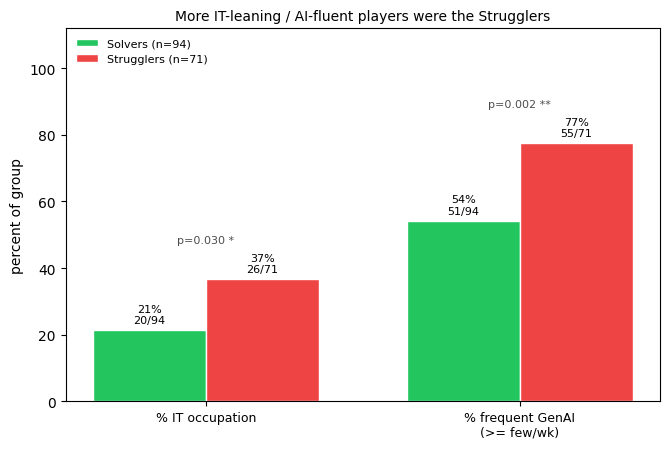

In [584]:
# --- Binary demographic splits: grouped single bars ---
# Same two comparisons the chi-square cell above tests (Solvers vs Strugglers), showing
# ONLY the informative category (% IT, % frequent GenAI user) so the takeaway reads fast.
# Reuses _won/_lost/FREQUENT_GENAI/_stats so bars and p-values match demo_won_lost_chi2.

METRICS = [
    ("% IT occupation", "occupation", lambda v: v == "it"),
    ("% frequent GenAI\n(>= few/wk)", "genai_usage", lambda v: v in FREQUENT_GENAI),
]
WON_C, LOST_C = "#22c55e", "#ef4444"

def _posfrac(rows, field, pred):
    """(pos_fraction, pos_n, total) over rows with a non-empty value."""
    vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
    pos = sum(1 for v in vals if pred(v)); tot = len(vals) or 1
    return pos / tot, pos, len(vals)

def _pstar(field, pred):
    def cnt(rows):
        vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
        p = sum(1 for v in vals if pred(v)); return p, len(vals) - p
    wp, wn = cnt(_won); lp, ln = cnt(_lost)
    _, p, _, exp = _stats.chi2_contingency(np.array([[wp, wn], [lp, ln]]), correction=False)
    star = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
    return p, star, exp.min()

fig, axb = plt.subplots(figsize=(6.8, 4.6))
x = np.arange(len(METRICS)); w = 0.36
for gi, (nm, rows, col) in enumerate([("Solvers", _won, WON_C), ("Strugglers", _lost, LOST_C)]):
    fr = [_posfrac(rows, f, p) for _, f, p in METRICS]
    xs = x + (gi - 0.5) * w
    axb.bar(xs, [100 * a[0] for a in fr], w, color=col, edgecolor="white",
            label=f"{nm} (n={fr[0][2]})")
    for xi, (frac, pn, tot) in zip(xs, fr):
        axb.text(xi, 100 * frac + 1.5, f"{100*frac:.0f}%\n{pn}/{tot}",
                 ha="center", va="bottom", fontsize=8)
# p-value sits just above the taller bar of each pair (clear of the legend)
for xi, (_, f, p) in zip(x, METRICS):
    pv, star, _ = _pstar(f, p)
    hmax = max(100 * _posfrac(_won, f, p)[0], 100 * _posfrac(_lost, f, p)[0])
    axb.text(xi, hmax + 11, f"p={pv:.3f} {star}", ha="center", fontsize=8, color="0.3")
axb.set_xticks(x); axb.set_xticklabels([m[0] for m in METRICS], fontsize=9)
axb.set_ylim(0, 112); axb.set_ylabel("percent of group")
axb.set_title("More IT-leaning / AI-fluent players were the Strugglers", fontsize=10)
axb.legend(fontsize=8, loc="upper left", frameon=False)       # left: clear of the right-hand p-value
plt.tight_layout(); plt.show()


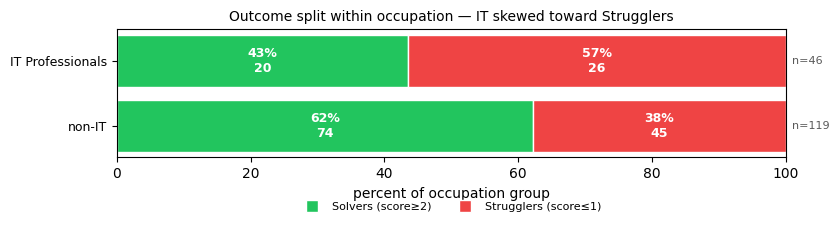

In [585]:
# --- Within-occupation outcome split: horizontal stacked bars ---
# Flips the conditioning of the charts above: instead of "% of Solvers who are IT",
# this asks "of IT professionals, what share were Solvers vs Strugglers?" Each row is a
# 100%-stacked bar (Solvers=green, Strugglers=red). non-IT row added for contrast.
def _demo(pids):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in pids if (RECORDINGS_BASE / pid / "demographics.json").exists()]
_won, _lost = _demo(good_pid), _demo(bad_pid)
WON_C, LOST_C = "#22c55e", "#ef4444"

ROWS = [
    ("IT Professionals", lambda d: d.get("occupation") == "it"),
    ("non-IT",           lambda d: d.get("occupation") not in (None, "", "it")),
]

fig, axo = plt.subplots(figsize=(8.5, 2.8))
y = np.arange(len(ROWS))[::-1]                      # first row on top
for yi, (label, pred) in zip(y, ROWS):
    s = sum(1 for d in _won  if pred(d))            # Solvers in this occupation
    t = sum(1 for d in _lost if pred(d))            # Strugglers in this occupation
    tot = s + t or 1
    sp, tp = 100 * s / tot, 100 * t / tot
    axo.barh(yi, sp,        color=WON_C,  edgecolor="white")
    axo.barh(yi, tp, left=sp, color=LOST_C, edgecolor="white")
    if sp > 8:
        axo.text(sp / 2, yi, f"{sp:.0f}%\n{s}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    if tp > 8:
        axo.text(sp + tp / 2, yi, f"{tp:.0f}%\n{t}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    axo.text(101, yi, f"n={tot}", va="center", ha="left", fontsize=8, color="0.35")

axo.set_yticks(y); axo.set_yticklabels([r[0] for r in ROWS], fontsize=9)
axo.set_xlim(0, 100); axo.set_xlabel("percent of occupation group")
axo.set_title("Outcome split within occupation \u2014 IT skewed toward Strugglers", fontsize=10)
handles = [plt.Line2D([0], [0], marker="s", ls="", ms=9, mfc=c, mec="white", label=nm)
           for nm, c in [("Solvers (score\u22652)", WON_C), ("Strugglers (score\u22641)", LOST_C)]]
axo.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.5),
           ncol=2, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()


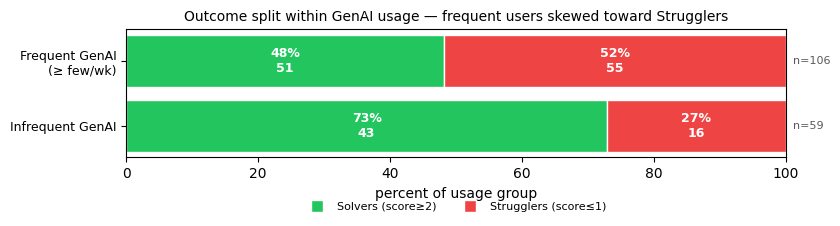

In [586]:
# --- Within-GenAI-usage outcome split: horizontal stacked bars ---
# Same flip as the occupation cell, but by AI fluency: "of frequent GenAI users, what
# share were Solvers vs Strugglers?" Frequent = few_times_week/daily/several_times_day
# (weekly counts as infrequent, matching FREQUENT_GENAI above). Rows 100%-stacked.
try:
    FREQUENT_GENAI
except NameError:
    FREQUENT_GENAI = {"few_times_week", "daily", "several_times_day"}
def _demo(pids):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in pids if (RECORDINGS_BASE / pid / "demographics.json").exists()]
_won, _lost = _demo(good_pid), _demo(bad_pid)
WON_C, LOST_C = "#22c55e", "#ef4444"

def _gv(d):
    v = d.get("genai_usage"); return None if v in (None, "") else v
ROWS = [
    ("Frequent GenAI\n(\u2265 few/wk)", lambda d: _gv(d) in FREQUENT_GENAI),
    ("Infrequent GenAI",              lambda d: _gv(d) is not None and _gv(d) not in FREQUENT_GENAI),
]

fig, axg = plt.subplots(figsize=(8.5, 2.8))
y = np.arange(len(ROWS))[::-1]                      # first row on top
for yi, (label, pred) in zip(y, ROWS):
    s = sum(1 for d in _won  if pred(d))            # Solvers in this usage band
    t = sum(1 for d in _lost if pred(d))            # Strugglers in this usage band
    tot = s + t or 1
    sp, tp = 100 * s / tot, 100 * t / tot
    axg.barh(yi, sp,        color=WON_C,  edgecolor="white")
    axg.barh(yi, tp, left=sp, color=LOST_C, edgecolor="white")
    if sp > 8:
        axg.text(sp / 2, yi, f"{sp:.0f}%\n{s}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    if tp > 8:
        axg.text(sp + tp / 2, yi, f"{tp:.0f}%\n{t}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    axg.text(101, yi, f"n={tot}", va="center", ha="left", fontsize=8, color="0.35")

axg.set_yticks(y); axg.set_yticklabels([r[0] for r in ROWS], fontsize=9)
axg.set_xlim(0, 100); axg.set_xlabel("percent of usage group")
axg.set_title("Outcome split within GenAI usage \u2014 frequent users skewed toward Strugglers", fontsize=10)
handles = [plt.Line2D([0], [0], marker="s", ls="", ms=9, mfc=c, mec="white", label=nm)
           for nm, c in [("Solvers (score\u22652)", WON_C), ("Strugglers (score\u22641)", LOST_C)]]
axg.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.5),
           ncol=2, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
